In [1]:
import numpy as np
import pandas as pd
import sys

from astropy.coordinates import Galactic, ICRS
from astropy import units as u
from modules.vr_opt import VrOpt

import nbimporter
import visualisations
import consensus_clusterings

sys.path.append('/Users/lui/Documents/3_semestr/Project/code/local-clustering/SemiMetricClustering')
from SemiMetricDensity import SemiMetricDensity

import shell_grid

In [2]:
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]
log = True

# Create 6D Gaussian data
np.random.seed(42) 
n = 500# 1000
X_bg = (np.random.rand(n*5, 6) - 0.5) * 50 #background dataset of random points uniformly distributed 6D

mu = np.array([-5, 5, 5, 5, -5, 5]) #first 3 for average position of the Cluster in 3D(XYZ). Last 3 for average velocities in (VxVyVz)
c_xx = c_yy = 20 #Variance of the average in x and y.
c_xy = 15 # correlation of x and y, positive -> there is a correlation 
c_zz = 3 #Variance in z 
c_uvw = 1
cov = np.diag([c_xx, c_yy, c_zz, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy #makes positive correlation of x and y
# Add signal
X_sig_1 = np.random.multivariate_normal(mu, cov, n//2) #generate n/2 data points based on mu and cov

# Second cluster
mu_2 = np.array([5, -5, -5, -5, 5, -5])
c_xx_2 = c_yy = 20
c_xy_2 = -15
c_zz_2 = 3
cov = np.diag([c_xx_2, c_yy, c_zz_2, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy_2
X_sig_2 = np.random.multivariate_normal(mu_2, cov, n//2)

# Additional clusters' parameters
# Cluster 3
mu_3 = np.array([10, -10, -10, -10, 10, -10])
c_xx_3 = c_yy_3 = 25 # More spread in X-Y plane
c_xy_3 = 10
c_zz_3 = 4
cov_3 = np.diag([c_xx_3, c_yy_3, c_zz_3, c_uvw, c_uvw, c_uvw])
cov_3[0, 1] = cov_3[1, 0] = c_xy_3
X_sig_3 = np.random.multivariate_normal(mu_3, cov_3, n//2)

# Cluster 4
mu_4 = np.array([-7, -7, -7, -7, -7, -7])
c_xx_4 = c_yy_4 = 30
c_xy_4 = -12
c_zz_4 = 5
cov_4 = np.diag([c_xx_4, c_yy_4, c_zz_4, c_uvw, c_uvw, c_uvw])
cov_4[0, 1] = cov_4[1, 0] = c_xy_4
X_sig_4 = np.random.multivariate_normal(mu_4, cov_4, n//2)

# Cluster 5
mu_5 = np.array([2, -2, -2, 2, 2, 2])
c_xx_5 = c_yy_5 = 35
c_xy_5 = 8
c_zz_5 = 6
cov_5 = np.diag([c_xx_5, c_yy_5, c_zz_5, c_uvw, c_uvw, c_uvw])
cov_5[0, 1] = cov_5[1, 0] = c_xy_5
X_sig_5 = np.random.multivariate_normal(mu_5, cov_5, n//2)

X = np.concatenate([X_bg, X_sig_1, X_sig_2, X_sig_3, X_sig_4, X_sig_5], axis=0) #5000 bg stars, and 5*500 cluster stars
labels = np.concatenate([np.zeros(n*5), np.ones(n//2), np.ones(n//2)*2, np.ones(n//2)*3, np.ones(n//2)*4, np.ones(n//2)*5])

df = pd.DataFrame(X, columns=['x', 'y', 'z', 'vx', 'vy', 'vz'])
# Transform to spherical coordinates
gal_coords = Galactic(
    u=df.x.values * u.pc,
    v=df.y.values * u.pc,
    w=df.z.values * u.pc,
    # velocities UVW
    U=df.vx.values * u.km / u.s,
    V=df.vy.values * u.km / u.s,
    W=df.vz.values * u.km / u.s,
    representation_type="cartesian",
    # Velocity representation
    differential_type="cartesian",
)
# transform to ICRS
icrs_coords = gal_coords.transform_to(ICRS())
icrs_coords.representation_type = "spherical"

ra = icrs_coords.ra.value
dec = icrs_coords.dec.value
dist = icrs_coords.distance.value
pmra = icrs_coords.pm_ra.value * np.cos(np.deg2rad(dec))
pmdec = icrs_coords.pm_dec.value
rv_calc = icrs_coords.radial_velocity.value

df['ra'] = ra
df['dec'] = dec
df['dist'] = dist
df['pmra'] = pmra
df['pmdec'] = pmdec
df['radial_velocity'] = rv_calc

df['vt_ra'] = df.pmra * df.dist * 4.74
df['vt_dec'] = df.pmdec * df.dist * 4.74

idx_cluster_1 = np.where(labels==1)[0]
idx_cluster_2 = np.where(labels==2)[0]
idx_cluster_3 = np.where(labels==3)[0]
idx_cluster_4 = np.where(labels==4)[0]
idx_cluster_5 = np.where(labels==5)[0]
idx_bg = np.where(labels==0)[0]

In [3]:
# Remove background
df_filtered, labels_filtered, _ = shell_grid.remove_background_noise(df, labels, ['x', 'y', 'z', 'vx', 'vy', 'vz'], k=10, detected_labels=None, print_info = True)

Initial dataset label distribution:
0.0    2500
1.0     250
2.0     250
3.0     250
4.0     250
5.0     250
Name: count, dtype: int64
Filtered dataset label distribution:
1.0    250
2.0    250
3.0    250
4.0    250
5.0    250
0.0     27
Name: count, dtype: int64
Total points before filtering: 3750, after filtering: 1277
Removed 2473 background points.


In [4]:
K = 9  
consensus_labels = shell_grid.run_shell_grid_consensus_clustering(
    df, K, labels, solver='cspa', consensus_nclass=K, random_state=42, colors=colors, alphas=alphas,
    zorders=zorders, num_rotations=3, rotation_axis='z', rotation_angle=None,
    num_shifts=3, num_sectors=3, num_shells=3, projection='xy', max_iter=1_000,
    method="random", theta=0.001, epsilon=0.0001,initial_partition=None, rho_multiplier=None,
    verbose=False, th_dist=5, dist_max=1e3, print_info=False, entire_G=False)

In [5]:
overall_nmi = consensus_clusterings.calculate_nmi_and_purity(consensus_labels, labels, background_label=0)

Overall NMI (ignoring background points): 0.6852

Cluster 0:
  - Number of points: 404
  - Purity (excluding background): 0.7080
  - True label distribution in this cluster:
    * Background noise: 154 points
    * True label 1.0: 2 points
    * True label 4.0: 71 points
    * True label 5.0: 177 points


Cluster 1:
  - Number of points: 404
  - Purity (excluding background): 0.8519
  - True label distribution in this cluster:
    * Background noise: 215 points
    * True label 1.0: 6 points
    * True label 2.0: 4 points
    * True label 4.0: 161 points
    * True label 5.0: 18 points


Cluster 2:
  - Number of points: 429
  - Purity (excluding background): 0.6909
  - True label distribution in this cluster:
    * Background noise: 264 points
    * True label 1.0: 114 points
    * True label 4.0: 11 points
    * True label 5.0: 40 points


Cluster 3:
  - Number of points: 404
  - Purity (excluding background): 0.8889
  - True label distribution in this cluster:
    * Background noise:

In [6]:
nmi = consensus_clusterings.calculate_nmi(consensus_labels, labels, background_label=0)
nmi

0.6851765629731946

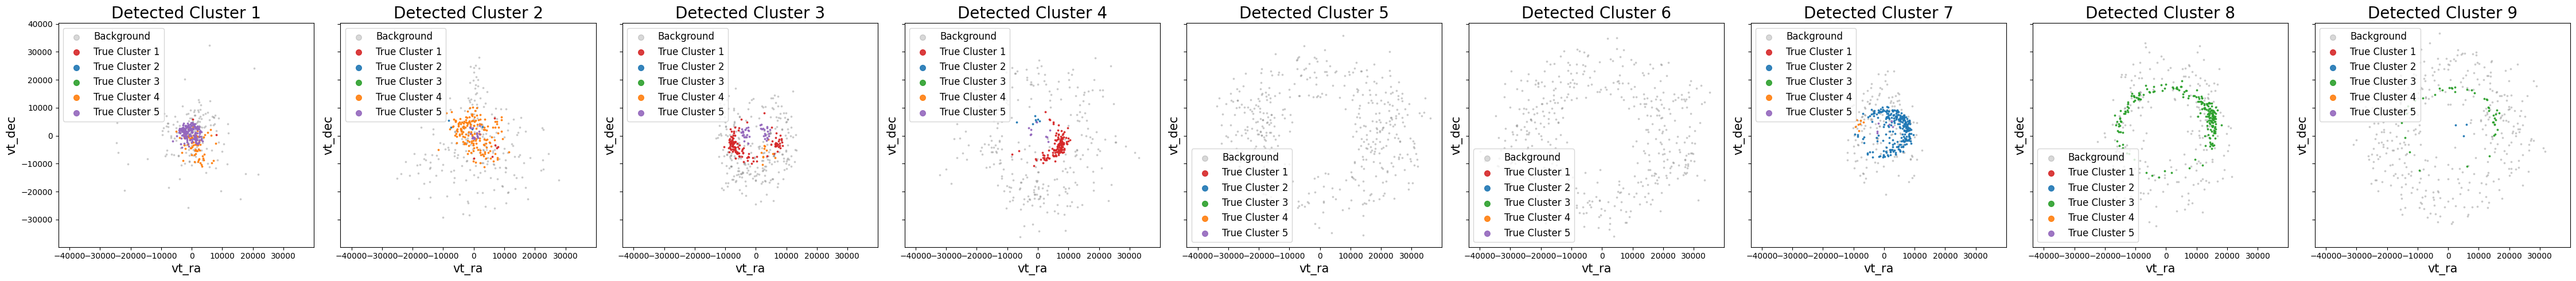

In [7]:
visualisations.visualise_cluster_result(
    df=df,
    cluster_labels=consensus_labels,
    true_labels=labels,
    K=len(np.unique(consensus_labels)),  
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

In [8]:
# Rerun shell grid and consensus clustering on specific detected cluster after previous run of the algorithm 
detected_cluster_id = 0
K = 5

clustering_results, subset_df, subset_true_labels, clustering_time = shell_grid.rerun_shell_grid_clustering_on_detected_cluster(
    df, labels, detected_cluster_id, consensus_labels, 
    K = K, solver = 'hbgf', consensus_nclass = K, num_rotations = 3, num_shifts = 3, 
    num_sectors = 3, num_shells = 3, projection='xy', colors=colors, 
    alphas=alphas, zorders=zorders, rotation_axis='z', 
    rotation_angle=30, max_iter=1000, method="random", 
    theta=0.001, epsilon=0.0001, th_dist=5, dist_max=1000, 
    print_info=False, entire_G=False)

In [9]:
overall_nmi = consensus_clusterings.calculate_nmi_and_purity(clustering_results, subset_true_labels, background_label=0)

Overall NMI (ignoring background points): 0.2085

Cluster 0:
  - Number of points: 73
  - Purity (excluding background): 0.6774
  - True label distribution in this cluster:
    * Background noise: 42 points
    * True label 1.0: 1 points
    * True label 4.0: 9 points
    * True label 5.0: 21 points


Cluster 1:
  - Number of points: 84
  - Purity (excluding background): 0.7609
  - True label distribution in this cluster:
    * Background noise: 38 points
    * True label 4.0: 35 points
    * True label 5.0: 11 points


Cluster 2:
  - Number of points: 63
  - Purity (excluding background): 0.5714
  - True label distribution in this cluster:
    * Background noise: 56 points
    * True label 1.0: 1 points
    * True label 4.0: 2 points
    * True label 5.0: 4 points


Cluster 3:
  - Number of points: 92
  - Purity (excluding background): 0.7126
  - True label distribution in this cluster:
    * Background noise: 5 points
    * True label 4.0: 25 points
    * True label 5.0: 62 points




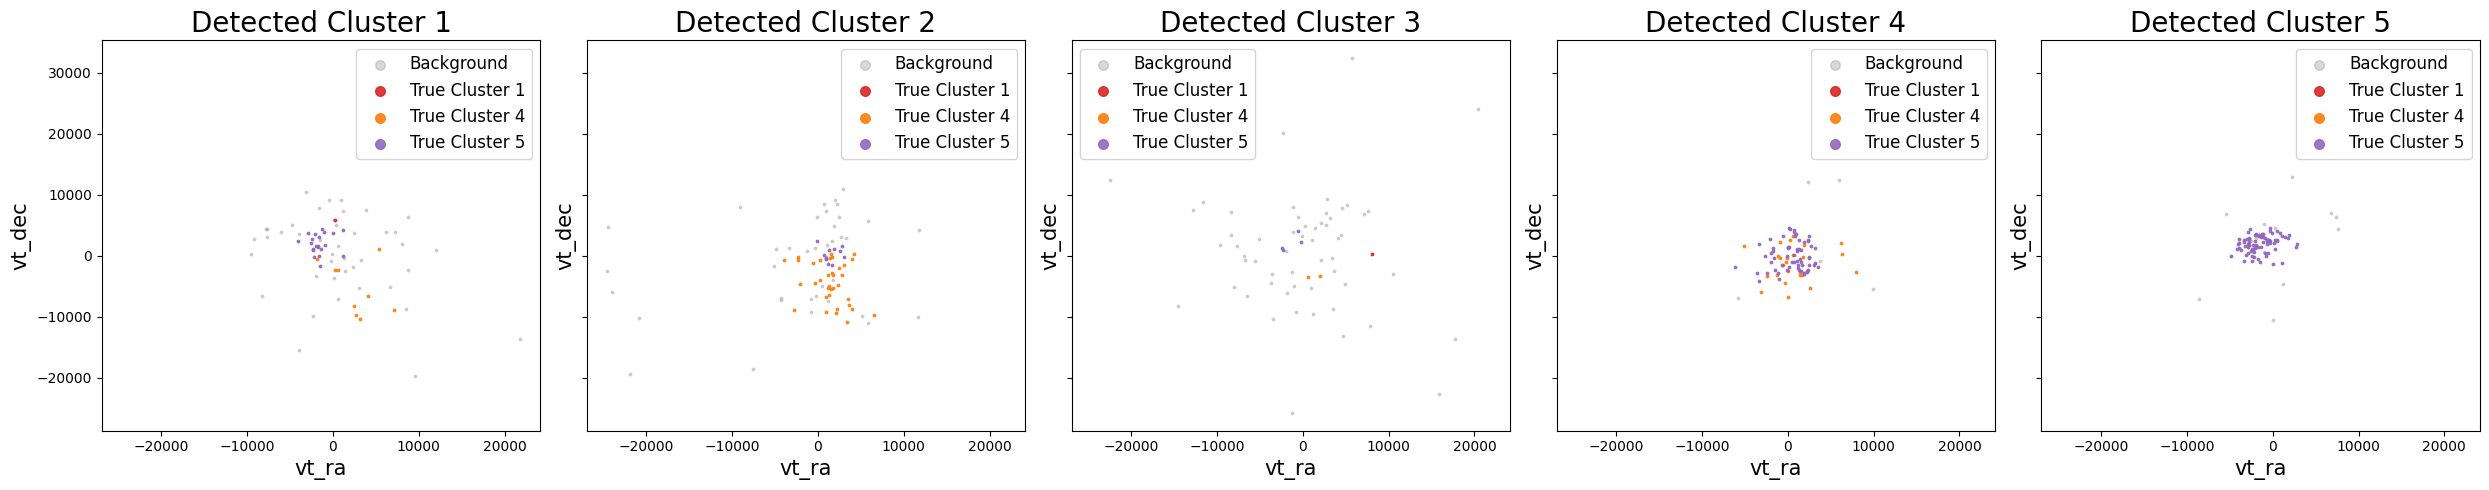

In [10]:
visualisations.visualise_cluster_result(
    df=subset_df,
    cluster_labels=clustering_results,
    true_labels=subset_true_labels,
    K=len(np.unique(clustering_results)),  
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

In [11]:
# Try different parameters combinations, save result to csv file; for filtered data from background points
K_values = [9]  
num_rotations_values = [2, 4]
num_shifts_values = [2]
num_shells_values = [2, 4]
num_sectors_values = [3]
rotation_angles = [30]
solvers = ['cspa', 'hgpa', 'mcla', 'hbgf', 'nmf']
consensus_nclass_values = [9, 6]
theta_values = [0.01, 0.001]
epsilon_values = [0.001, 0.0001]
th_dist_values = [5, 15, 25, 45, None]
dist_max_values = [1000]

In [12]:
results_df_filtered = shell_grid.experiment_shell_grid_clustering(df_filtered, labels_filtered, 
                                     K_values, num_rotations_values, num_shifts_values, 
                                     num_shells_values, num_sectors_values, rotation_angles, 
                                     solvers, consensus_nclass_values, theta_values, 
                                     epsilon_values, th_dist_values, dist_max_values, 
                                     projection='xy', colors=colors, alphas=alphas, 
                                     zorders=zorders, output_file='clustering_results_df_filtered.csv')

Results saved to clustering_results_df_filtered.csv


,K,Num Rotations,Num Shifts,Num Shells,Num Sectors,Rotation Angle,Solver,Consensus NClass,Theta,Epsilon,Th_dist,Dist_max,NMI,Runtime
0,9,2,2,2,3,30,cspa,9,0.010,0.0010,5.0,1000,0.505376,5.716920
1,9,2,2,2,3,30,cspa,9,0.010,0.0010,15.0,1000,0.307205,6.331250
2,9,2,2,2,3,30,cspa,9,0.010,0.0010,25.0,1000,0.342273,6.479567
3,9,2,2,2,3,30,cspa,9,0.010,0.0010,45.0,1000,0.346005,5.610921
4,9,2,2,2,3,30,cspa,9,0.010,0.0010,NaN,1000,0.381640,6.094241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,9,4,2,4,3,30,nmf,6,0.001,0.0001,5.0,1000,0.601194,5.862499
796,9,4,2,4,3,30,nmf,6,0.001,0.0001,15.0,1000,0.271080,5.984789
797,9,4,2,4,3,30,nmf,6,0.001,0.0001,25.0,1000,0.002783,5.451636
798,9,4,2,4,3,30,nmf,6,0.001,0.0001,45.0,1000,0.331380,5.735310


In [15]:
best_options_filtered, worst_options_filtered = shell_grid.get_best_and_worst_options("clustering_results_df_filtered_shellgrid.csv", top_n=10)

In [16]:
print("Top 10 best configurations:")
best_options_filtered

Top 10 best configurations:


,K,Num Rotations,Num Shifts,Num Shells,Num Sectors,Rotation Angle,Solver,Consensus NClass,Theta,Epsilon,Th_dist,Dist_max,NMI,Runtime
185,9,2,2,2,3,30,nmf,6,0.010,0.0001,5.0,1000,0.680292,3.425940
585,9,4,2,2,3,30,nmf,6,0.010,0.0001,5.0,1000,0.642401,6.803936
785,9,4,2,4,3,30,nmf,6,0.010,0.0001,5.0,1000,0.633527,5.856054
560,9,4,2,2,3,30,nmf,9,0.010,0.0010,5.0,1000,0.631959,7.900256
590,9,4,2,2,3,30,nmf,6,0.001,0.0010,5.0,1000,0.629411,6.538389
580,9,4,2,2,3,30,nmf,6,0.010,0.0010,5.0,1000,0.629262,7.413596
790,9,4,2,4,3,30,nmf,6,0.001,0.0010,5.0,1000,0.614603,5.325401
180,9,2,2,2,3,30,nmf,6,0.010,0.0010,5.0,1000,0.612334,3.450945
780,9,4,2,4,3,30,nmf,6,0.010,0.0010,5.0,1000,0.607757,5.717130
795,9,4,2,4,3,30,nmf,6,0.001,0.0001,5.0,1000,0.601194,5.862499


In [17]:
print("Top 10 worst configurations:")
worst_options_filtered

Top 10 worst configurations:


,K,Num Rotations,Num Shifts,Num Shells,Num Sectors,Rotation Angle,Solver,Consensus NClass,Theta,Epsilon,Th_dist,Dist_max,NMI,Runtime
797,9,4,2,4,3,30,nmf,6,0.001,0.0001,25.0,1000,0.002783,5.451636
397,9,2,2,4,3,30,nmf,6,0.001,0.0001,25.0,1000,0.003184,2.921323
777,9,4,2,4,3,30,nmf,9,0.001,0.0001,25.0,1000,0.004552,6.131425
377,9,2,2,4,3,30,nmf,9,0.001,0.0001,25.0,1000,0.008232,2.922606
637,9,4,2,4,3,30,cspa,6,0.001,0.0001,25.0,1000,0.011413,9.942657
617,9,4,2,4,3,30,cspa,9,0.001,0.0001,25.0,1000,0.012173,9.933255
297,9,2,2,4,3,30,mcla,9,0.001,0.0001,25.0,1000,0.016870,3.522811
197,9,2,2,2,3,30,nmf,6,0.001,0.0001,25.0,1000,0.022480,2.922553
454,9,4,2,2,3,30,hgpa,9,0.001,0.0010,NaN,1000,0.031483,4.471976
196,9,2,2,2,3,30,nmf,6,0.001,0.0001,15.0,1000,0.031942,2.919347


In [11]:
# Try different parameters combinations, save result to csv file; for unfiltered data from background points
K_values = [9]  
num_rotations_values = [2, 4]
num_shifts_values = [2]
num_shells_values = [2, 4]
num_sectors_values = [3]
rotation_angles = [30]
solvers = ['cspa', 'mcla', 'hbgf', 'nmf']
consensus_nclass_values = [9, 6]
theta_values = [0.01]
epsilon_values = [0.001]
th_dist_values = [2, 5, 15]
dist_max_values = [1000]

In [12]:
results_df_nonfiltered = shell_grid.experiment_shell_grid_clustering(df, labels, 
                                     K_values, num_rotations_values, num_shifts_values, 
                                     num_shells_values, num_sectors_values, rotation_angles, 
                                     solvers, consensus_nclass_values, theta_values, 
                                     epsilon_values, th_dist_values, dist_max_values, 
                                     projection='xy', colors=colors, alphas=alphas, 
                                     zorders=zorders, output_file='clustering_results_df_nonfiltered.csv')

Running Experiments: 100%|██████████| 96/96 [1:26:40<00:00, 54.17s/it] 

Results saved to clustering_results_df_nonfiltered.csv


In [18]:
best_options_nonfiltered, worst_options_nonfiltered = shell_grid.get_best_and_worst_options("clustering_results_df_nonfiltered_shellgrid.csv", top_n=10)

In [19]:
print("Top 10 best configurations:")
best_options_nonfiltered

Top 10 best configurations:


,K,Num Rotations,Num Shifts,Num Shells,Num Sectors,Rotation Angle,Solver,Consensus NClass,Theta,Epsilon,Th_dist,Dist_max,NMI,Runtime
42,9,2,2,4,3,30,nmf,9,0.01,0.001,2,1000,0.873383,25.587382
33,9,2,2,4,3,30,mcla,6,0.01,0.001,2,1000,0.858811,18.712640
81,9,4,2,4,3,30,mcla,6,0.01,0.001,2,1000,0.843187,37.292466
72,9,4,2,4,3,30,cspa,9,0.01,0.001,2,1000,0.838174,116.475058
21,9,2,2,2,3,30,nmf,6,0.01,0.001,2,1000,0.836944,25.771613
57,9,4,2,2,3,30,mcla,6,0.01,0.001,2,1000,0.827030,38.855554
43,9,2,2,4,3,30,nmf,9,0.01,0.001,5,1000,0.821995,29.568941
60,9,4,2,2,3,30,hbgf,9,0.01,0.001,2,1000,0.818774,39.319508
91,9,4,2,4,3,30,nmf,9,0.01,0.001,5,1000,0.810208,48.846409
78,9,4,2,4,3,30,mcla,9,0.01,0.001,2,1000,0.806318,37.535071


In [20]:
print("\nTop 10 worst configurations:")
worst_options_nonfiltered


Top 10 worst configurations:


,K,Num Rotations,Num Shifts,Num Shells,Num Sectors,Rotation Angle,Solver,Consensus NClass,Theta,Epsilon,Th_dist,Dist_max,NMI,Runtime
38,9,2,2,4,3,30,hbgf,9,0.01,0.001,15,1000,0.299392,19.457101
86,9,4,2,4,3,30,hbgf,9,0.01,0.001,15,1000,0.349620,38.369600
14,9,2,2,2,3,30,hbgf,9,0.01,0.001,15,1000,0.356308,20.274715
74,9,4,2,4,3,30,cspa,9,0.01,0.001,15,1000,0.361103,160.837877
41,9,2,2,4,3,30,hbgf,6,0.01,0.001,15,1000,0.380498,19.539951
29,9,2,2,4,3,30,cspa,6,0.01,0.001,15,1000,0.385696,130.821706
2,9,2,2,2,3,30,cspa,9,0.01,0.001,15,1000,0.386291,133.214196
89,9,4,2,4,3,30,hbgf,6,0.01,0.001,15,1000,0.394518,37.758476
23,9,2,2,2,3,30,nmf,6,0.01,0.001,15,1000,0.395741,30.537672
44,9,2,2,4,3,30,nmf,9,0.01,0.001,15,1000,0.398210,32.259306


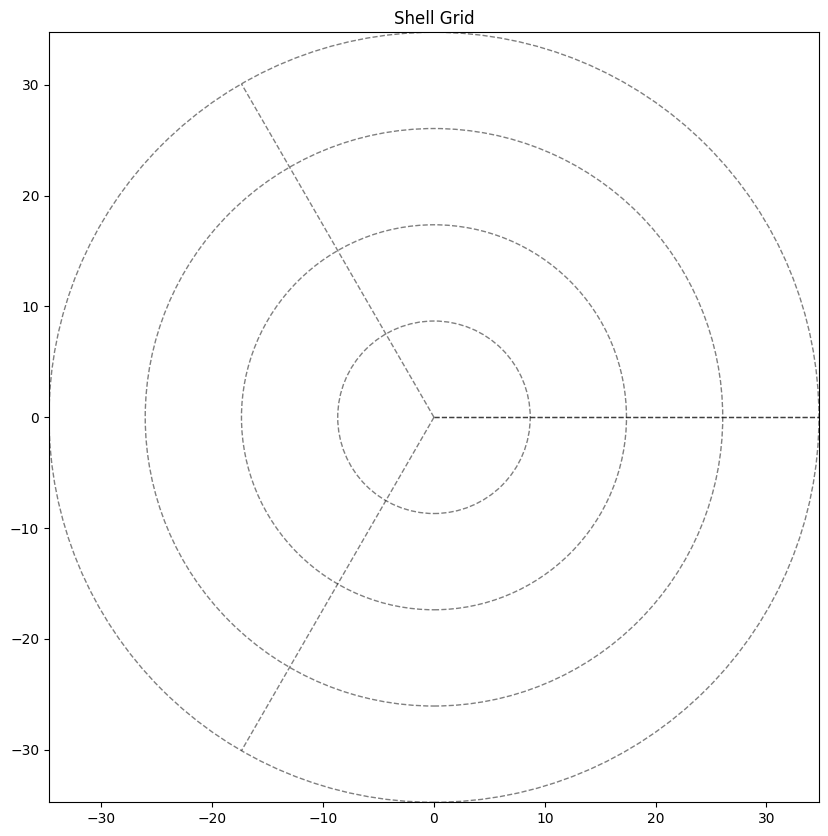

Rotation 1: Angle 0.0 degrees
  Shift 1:
    Sector 1: 9 clusters, Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8], Points: 466
      True label counts in sector 1: {0.0: 460, 3.0: 6}
      Detected cluster counts in sector 1: {0: 57, 1: 35, 2: 56, 3: 30, 4: 60, 5: 48, 6: 67, 7: 71, 8: 42}


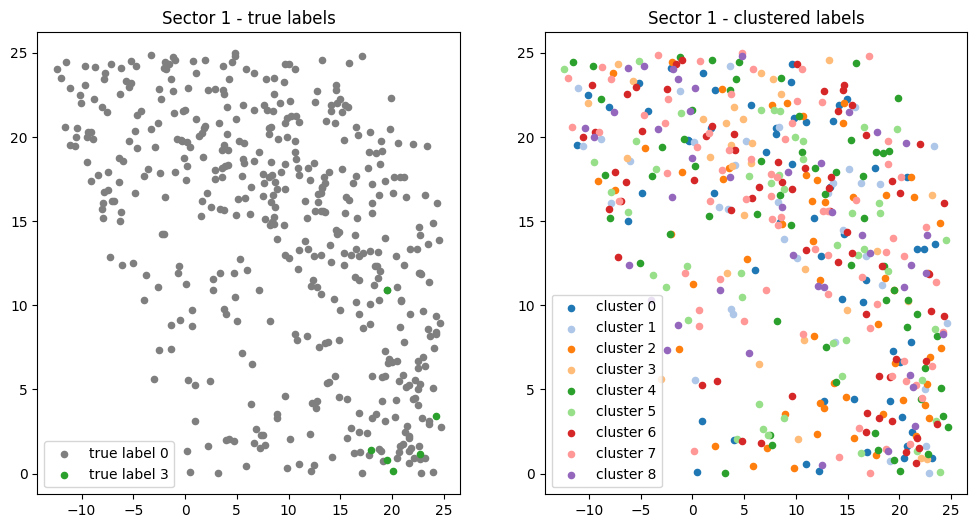

    Sector 2: 9 clusters, Labels: [9, 10, 11, 12, 13, 14, 15, 16, 17], Points: 462
      True label counts in sector 2: {0.0: 455, 4.0: 6, 1.0: 1}
      Detected cluster counts in sector 2: {9: 88, 10: 53, 11: 52, 12: 31, 13: 49, 14: 56, 15: 29, 16: 45, 17: 59}


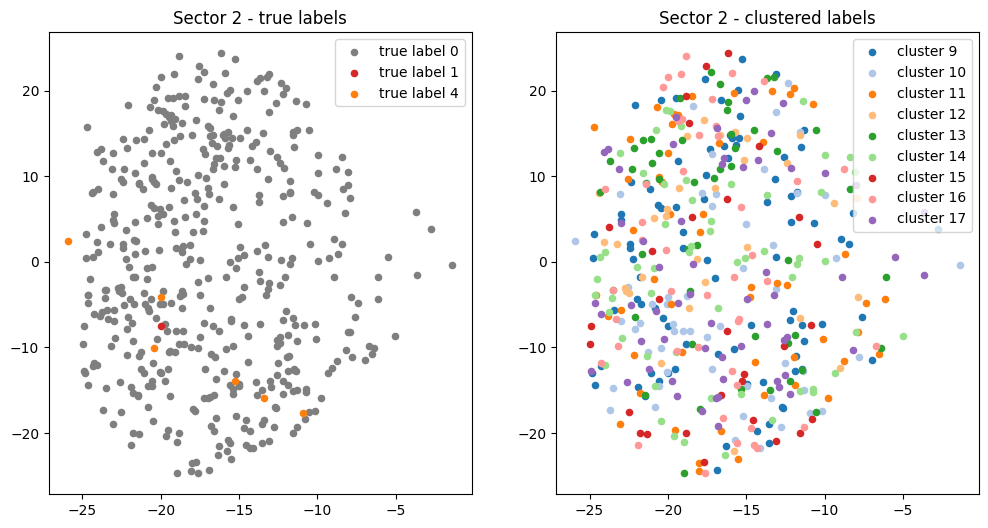

    Sector 3: 8 clusters, Labels: [18, 19, 20, 21, 22, 23, 24, 25], Points: 508
      True label counts in sector 3: {0.0: 441, 3.0: 57, 2.0: 5, 4.0: 5}
      Detected cluster counts in sector 3: {18: 89, 19: 31, 20: 132, 21: 85, 22: 19, 23: 63, 24: 67, 25: 22}


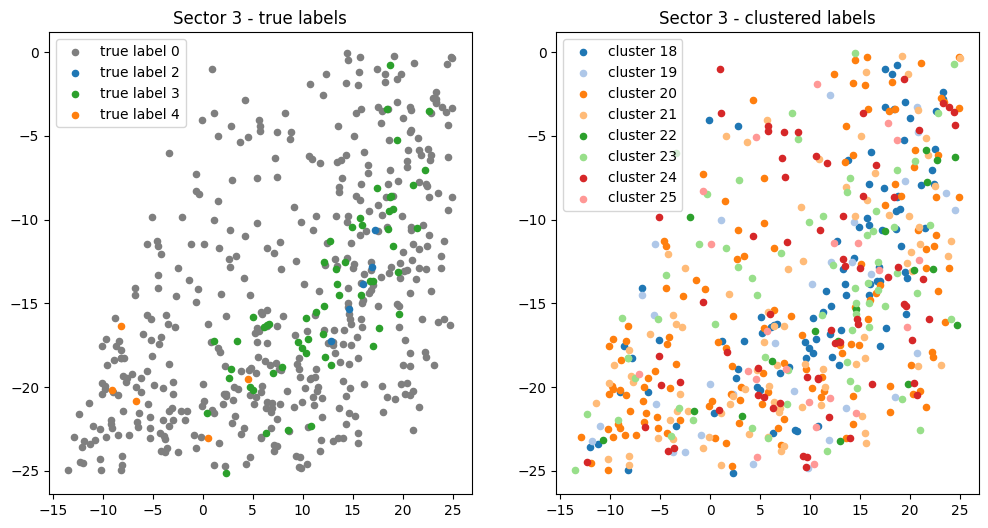

    Sector 4: 4 clusters, Labels: [26, 27, 28, 29], Points: 612
      True label counts in sector 4: {0.0: 234, 3.0: 178, 2.0: 91, 4.0: 72, 5.0: 37}
      Detected cluster counts in sector 4: {26: 291, 27: 186, 28: 133, 29: 2}


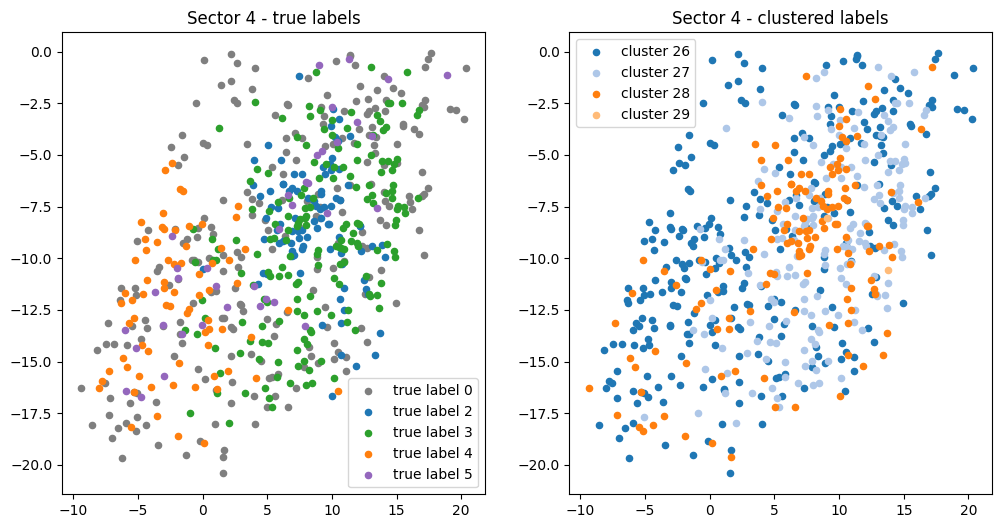

    Sector 5: 9 clusters, Labels: [30, 31, 32, 33, 34, 35, 36, 37, 38], Points: 178
      True label counts in sector 5: {0.0: 178}
      Detected cluster counts in sector 5: {30: 26, 31: 12, 32: 19, 33: 19, 34: 17, 35: 24, 36: 23, 37: 19, 38: 19}


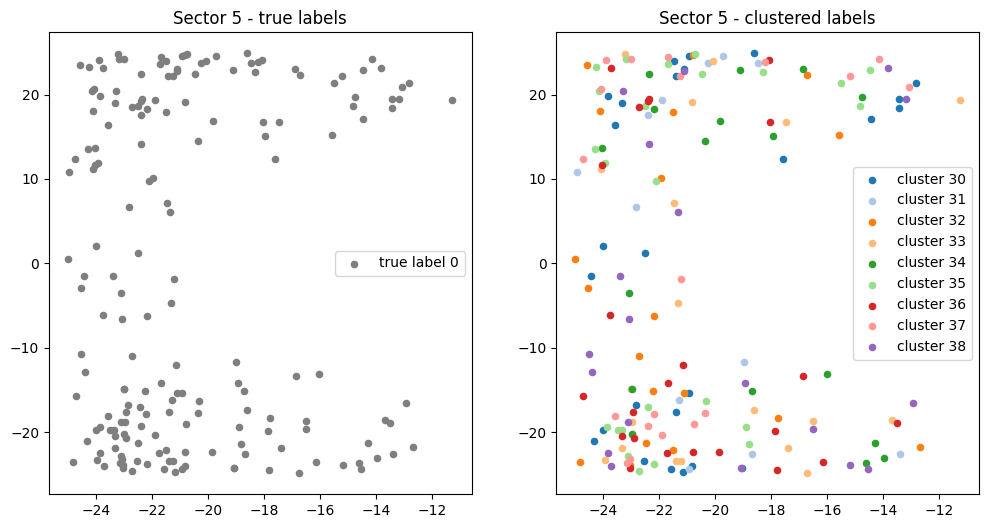

    Sector 6: 4 clusters, Labels: [39, 40, 41, 42], Points: 418
      True label counts in sector 6: {0.0: 190, 4.0: 131, 1.0: 84, 5.0: 11, 2.0: 2}
      Detected cluster counts in sector 6: {39: 176, 40: 139, 41: 92, 42: 11}


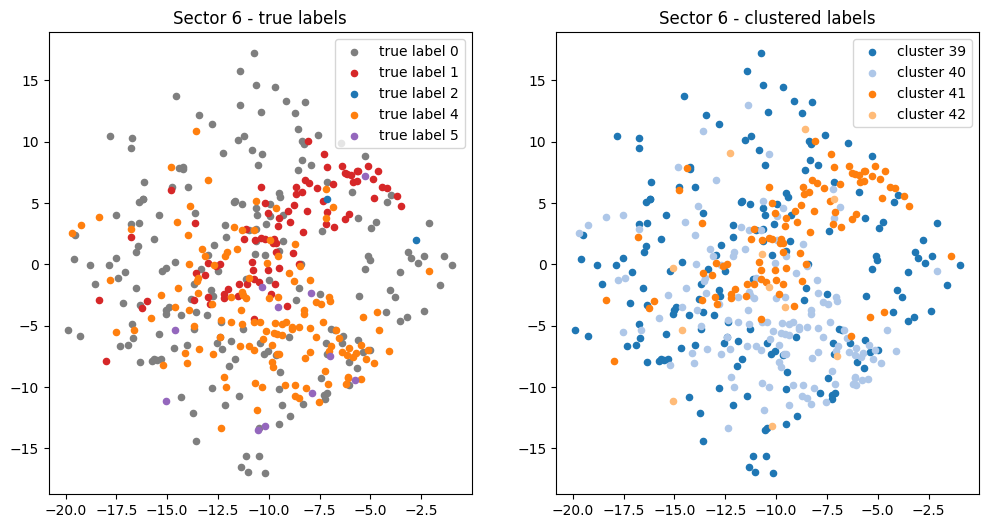

    Sector 7: 9 clusters, Labels: [43, 44, 45, 46, 47, 48, 49, 50, 51], Points: 103
      True label counts in sector 7: {0.0: 103}
      Detected cluster counts in sector 7: {43: 6, 44: 12, 45: 17, 46: 11, 47: 7, 48: 16, 49: 12, 50: 8, 51: 14}


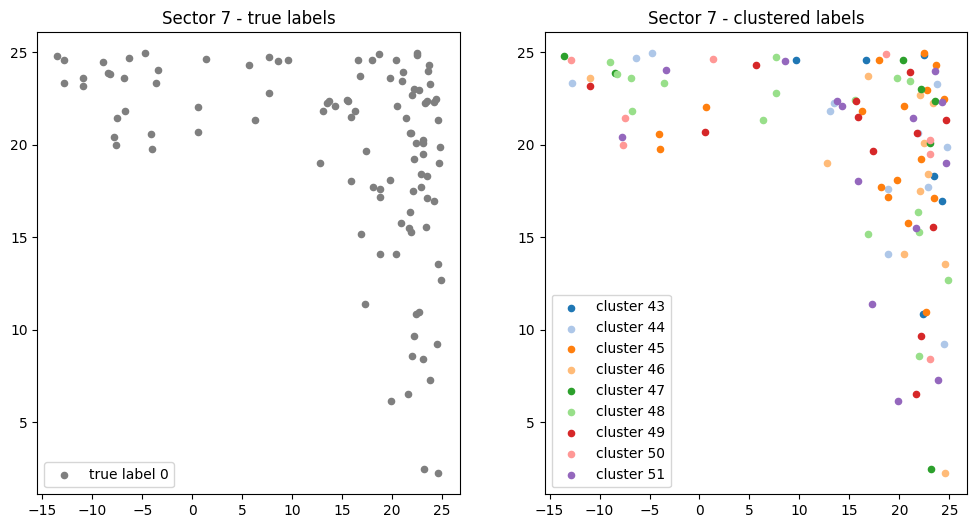

    Sector 8: 9 clusters, Labels: [52, 53, 54, 55, 56, 57, 58, 59, 60], Points: 280
      True label counts in sector 8: {0.0: 211, 1.0: 42, 5.0: 19, 3.0: 8}
      Detected cluster counts in sector 8: {52: 65, 53: 50, 54: 64, 55: 14, 56: 5, 57: 4, 58: 33, 59: 29, 60: 16}


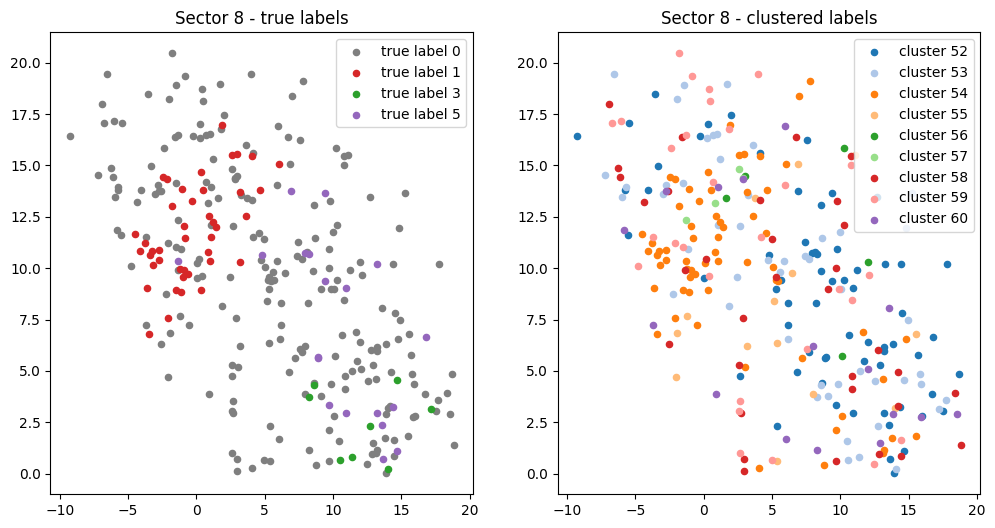

    Sector 9: 9 clusters, Labels: [61, 62, 63, 64, 65, 66, 67, 68, 69], Points: 129
      True label counts in sector 9: {0.0: 129}
      Detected cluster counts in sector 9: {61: 7, 62: 17, 63: 18, 64: 20, 65: 8, 66: 14, 67: 20, 68: 12, 69: 13}


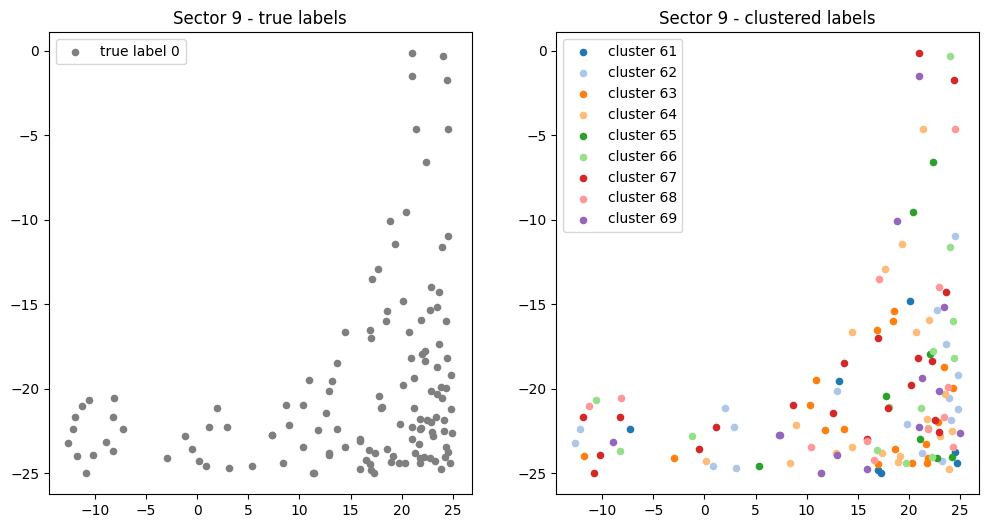

    Sector 10: 6 clusters, Labels: [70, 71, 72, 73, 74, 75], Points: 185
      True label counts in sector 10: {1.0: 79, 0.0: 35, 5.0: 29, 2.0: 23, 4.0: 19}
      Detected cluster counts in sector 10: {70: 2, 71: 1, 72: 3, 73: 92, 74: 80, 75: 7}


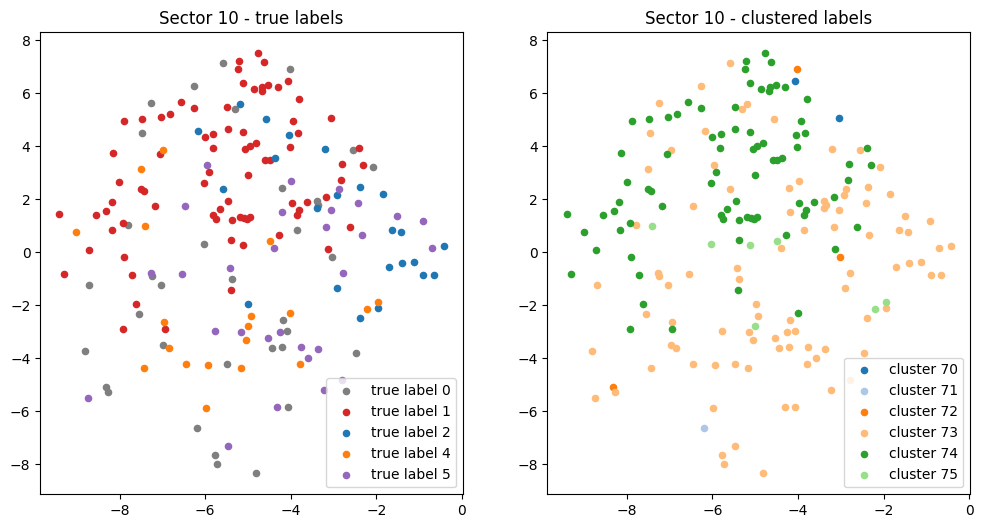

    Sector 11: 5 clusters, Labels: [76, 77, 78, 79, 80], Points: 239
      True label counts in sector 11: {2.0: 100, 5.0: 87, 0.0: 36, 4.0: 15, 3.0: 1}
      Detected cluster counts in sector 11: {76: 8, 77: 1, 78: 41, 79: 102, 80: 87}


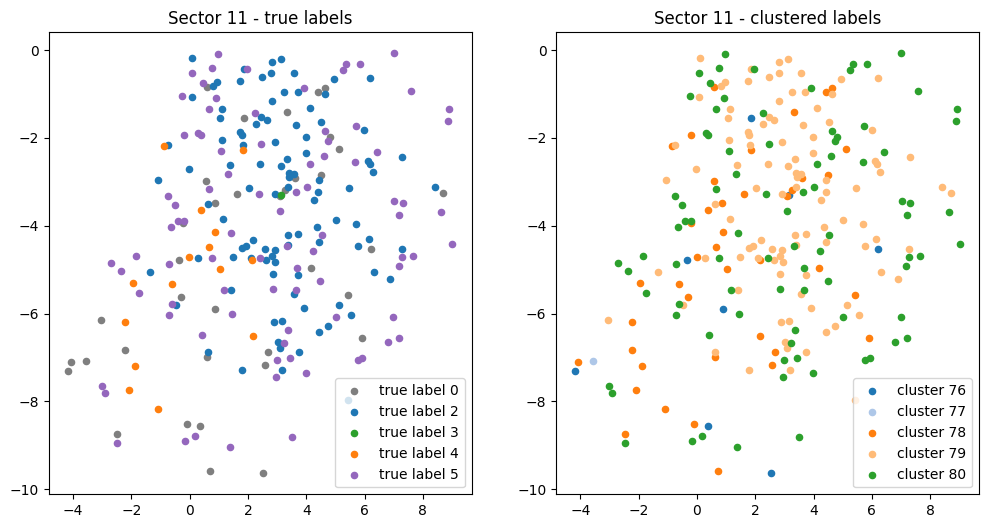

    Sector 12: 6 clusters, Labels: [81, 82, 83, 84, 85, 86], Points: 3750
      True label counts in sector 12: {0.0: 2500, 3.0: 250, 1.0: 250, 4.0: 250, 2.0: 250, 5.0: 250}
      Detected cluster counts in sector 12: {81: 1448, 82: 417, 83: 371, 84: 576, 85: 435, 86: 503}


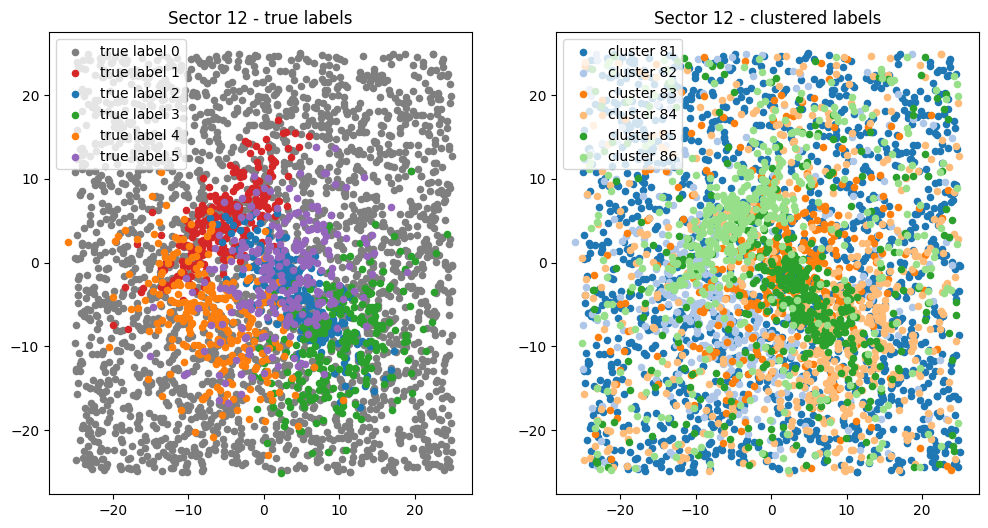

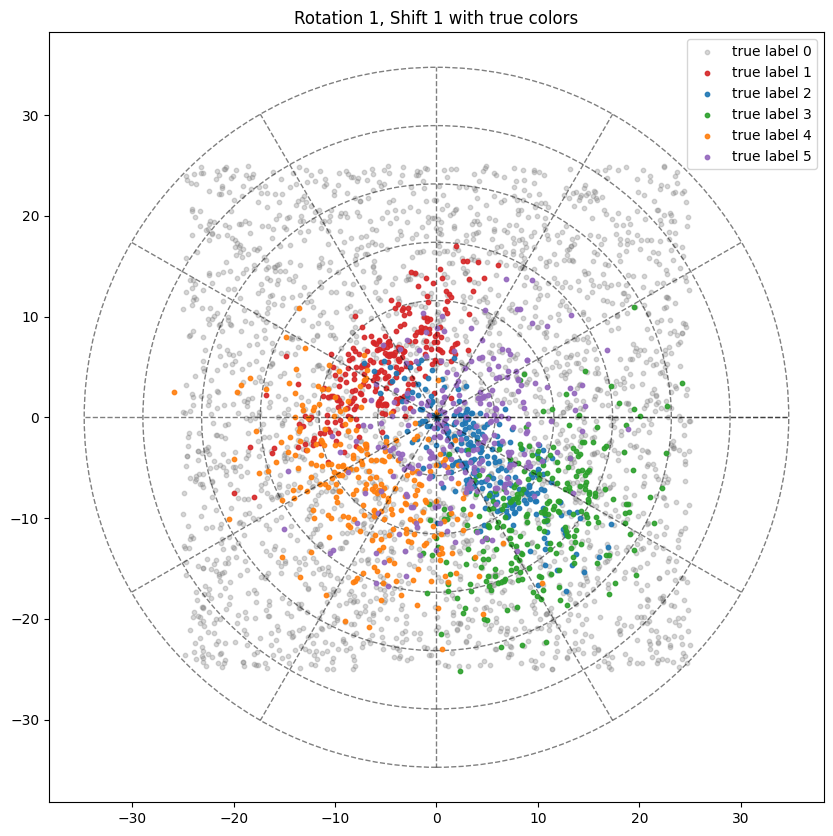

  Shift 2:
    Sector 1: 9 clusters, Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8], Points: 466
      True label counts in sector 1: {0.0: 460, 3.0: 6}
      Detected cluster counts in sector 1: {0: 72, 1: 73, 2: 66, 3: 51, 4: 72, 5: 25, 6: 36, 7: 22, 8: 49}


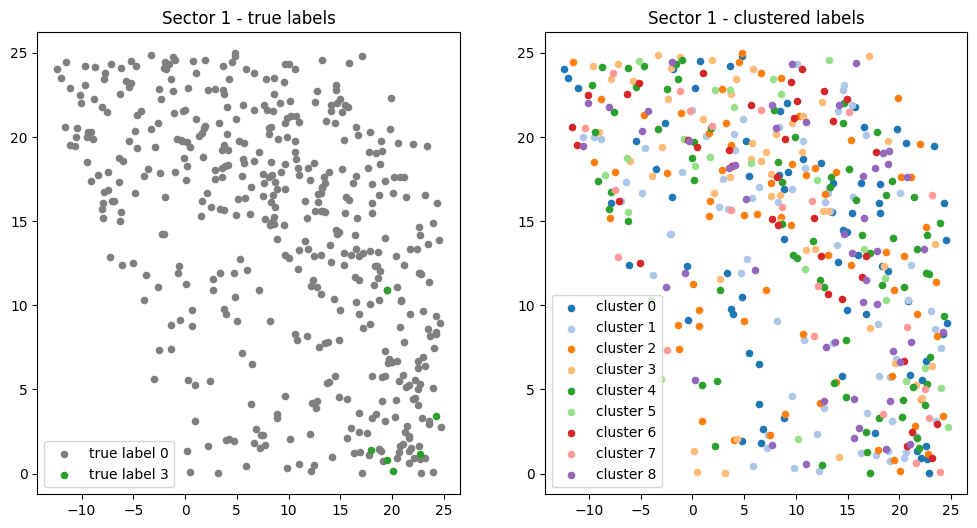

    Sector 2: 9 clusters, Labels: [9, 10, 11, 12, 13, 14, 15, 16, 17], Points: 462
      True label counts in sector 2: {0.0: 455, 4.0: 6, 1.0: 1}
      Detected cluster counts in sector 2: {9: 44, 10: 84, 11: 104, 12: 30, 13: 36, 14: 40, 15: 40, 16: 45, 17: 39}


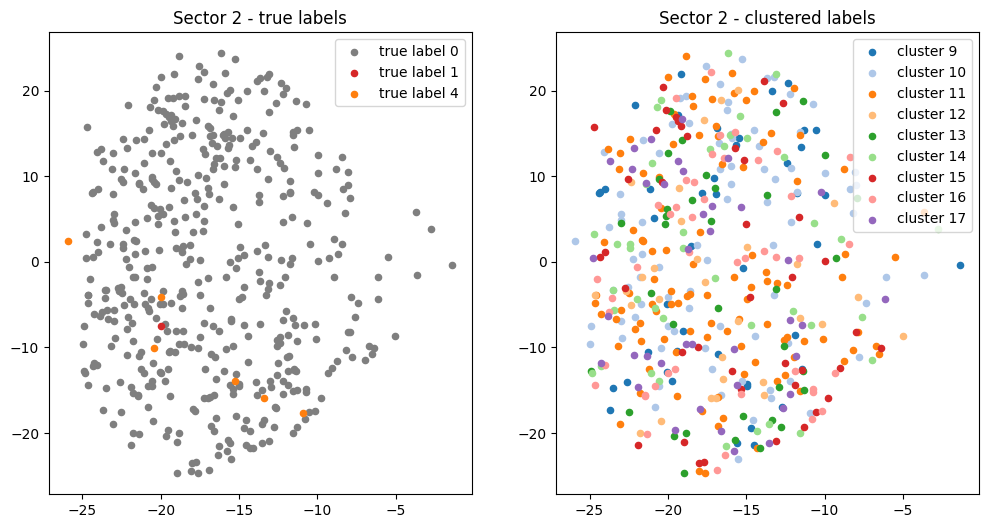

    Sector 3: 9 clusters, Labels: [18, 19, 20, 21, 22, 23, 24, 25, 26], Points: 508
      True label counts in sector 3: {0.0: 441, 3.0: 57, 2.0: 5, 4.0: 5}
      Detected cluster counts in sector 3: {18: 43, 19: 52, 20: 13, 21: 61, 22: 75, 23: 117, 24: 36, 25: 89, 26: 22}


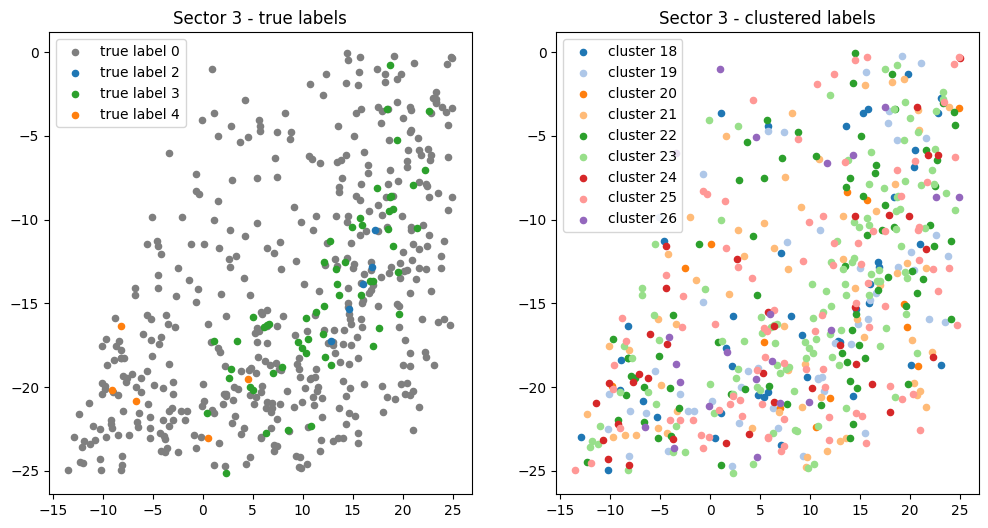

    Sector 4: 6 clusters, Labels: [27, 28, 29, 30, 31, 32], Points: 612
      True label counts in sector 4: {0.0: 234, 3.0: 178, 2.0: 91, 4.0: 72, 5.0: 37}
      Detected cluster counts in sector 4: {27: 186, 28: 300, 29: 1, 30: 1, 31: 121, 32: 3}


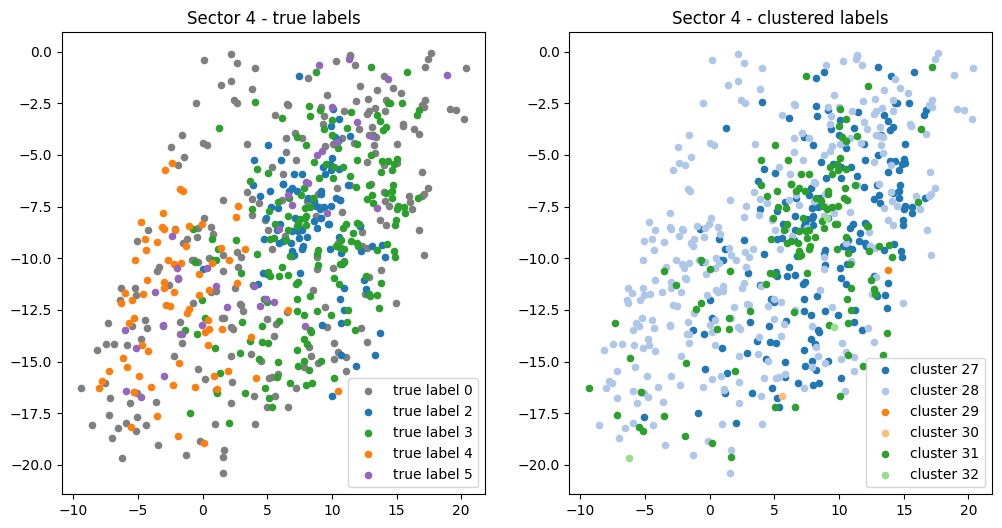

    Sector 5: 9 clusters, Labels: [33, 34, 35, 36, 37, 38, 39, 40, 41], Points: 178
      True label counts in sector 5: {0.0: 178}
      Detected cluster counts in sector 5: {33: 33, 34: 18, 35: 13, 36: 19, 37: 20, 38: 13, 39: 27, 40: 19, 41: 16}


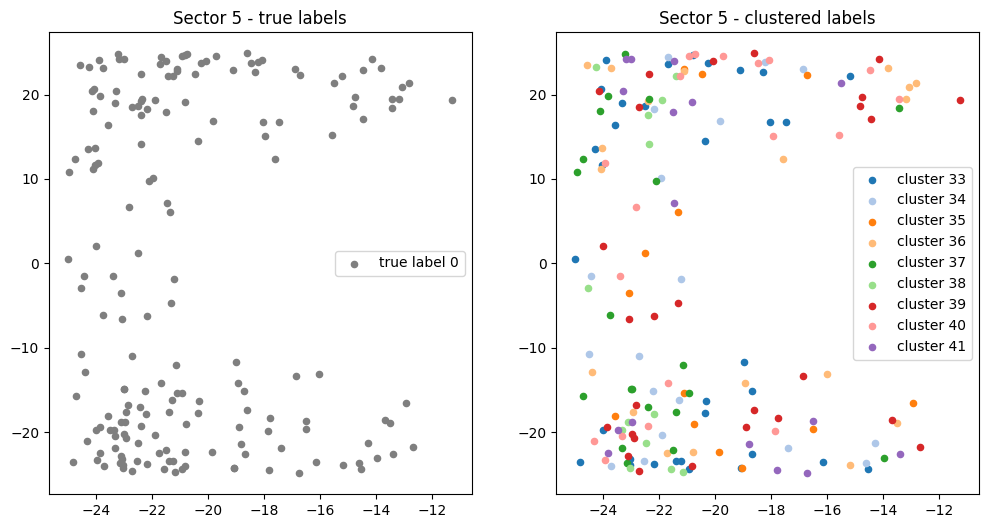

    Sector 6: 4 clusters, Labels: [42, 43, 44, 45], Points: 418
      True label counts in sector 6: {0.0: 190, 4.0: 131, 1.0: 84, 5.0: 11, 2.0: 2}
      Detected cluster counts in sector 6: {42: 95, 43: 182, 44: 1, 45: 140}


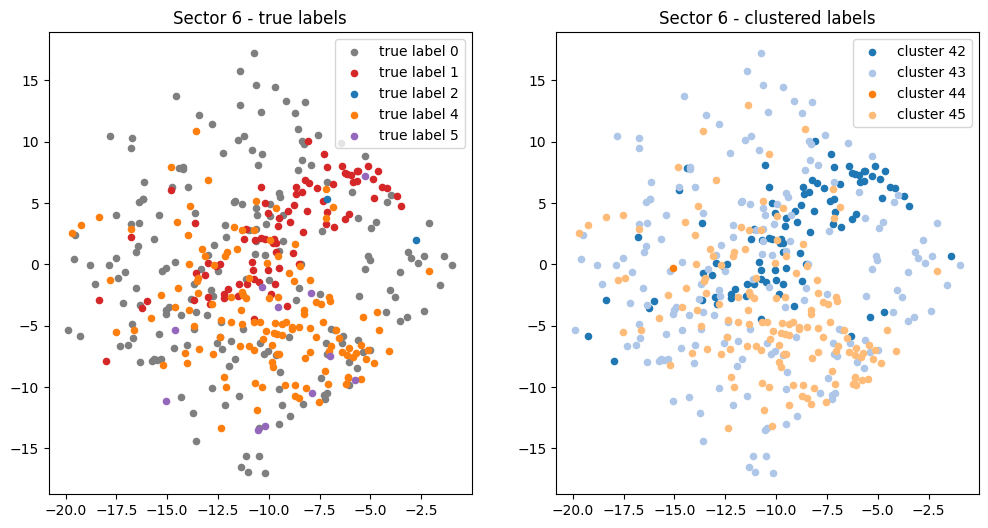

    Sector 7: 9 clusters, Labels: [46, 47, 48, 49, 50, 51, 52, 53, 54], Points: 103
      True label counts in sector 7: {0.0: 103}
      Detected cluster counts in sector 7: {46: 11, 47: 8, 48: 12, 49: 13, 50: 17, 51: 12, 52: 12, 53: 8, 54: 10}


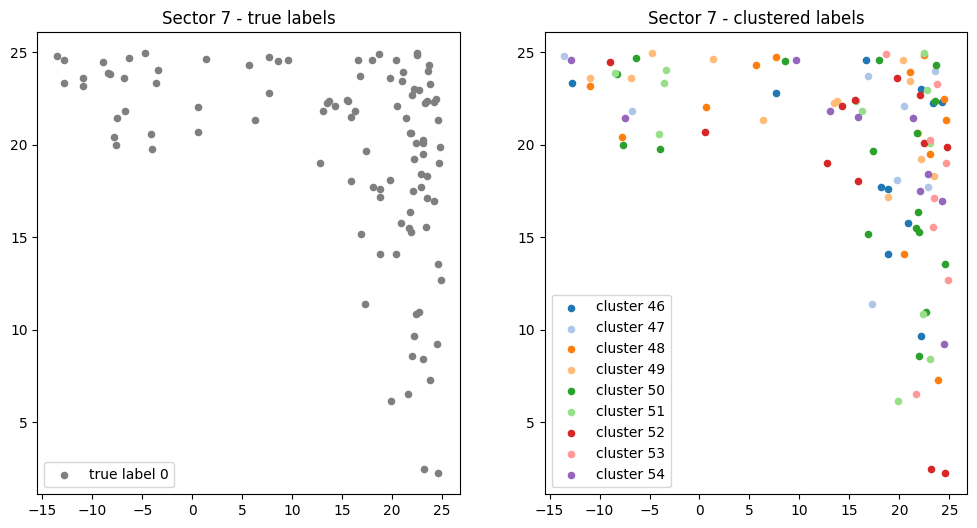

    Sector 8: 9 clusters, Labels: [55, 56, 57, 58, 59, 60, 61, 62, 63], Points: 280
      True label counts in sector 8: {0.0: 211, 1.0: 42, 5.0: 19, 3.0: 8}
      Detected cluster counts in sector 8: {55: 62, 56: 41, 57: 12, 58: 63, 59: 42, 60: 14, 61: 11, 62: 10, 63: 25}


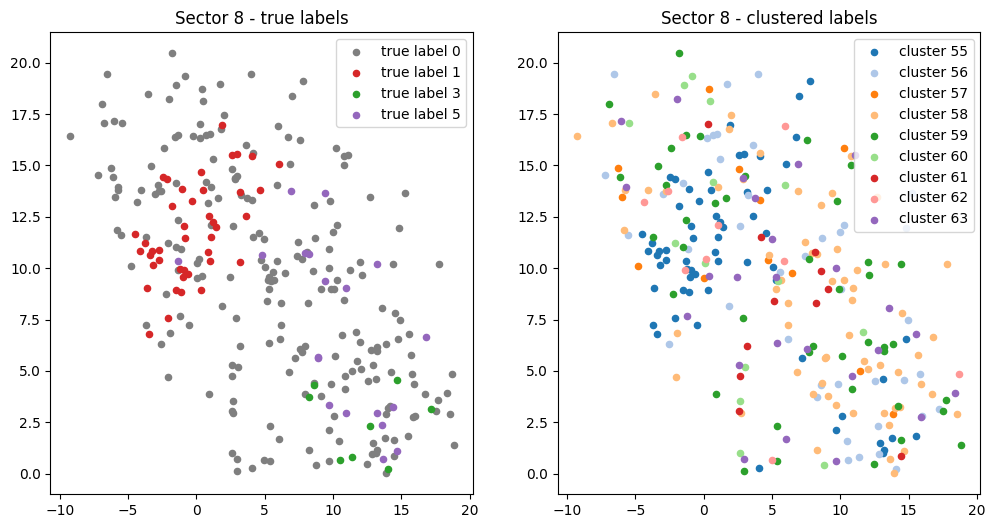

    Sector 9: 9 clusters, Labels: [64, 65, 66, 67, 68, 69, 70, 71, 72], Points: 129
      True label counts in sector 9: {0.0: 129}
      Detected cluster counts in sector 9: {64: 18, 65: 11, 66: 13, 67: 11, 68: 16, 69: 20, 70: 16, 71: 13, 72: 11}


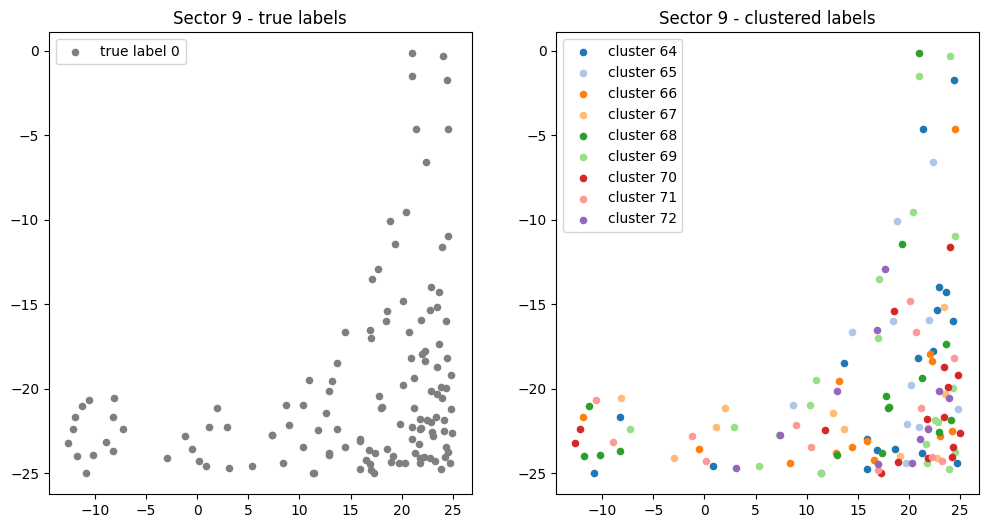

    Sector 10: 9 clusters, Labels: [73, 74, 75, 76, 77, 78, 79, 80, 81], Points: 185
      True label counts in sector 10: {1.0: 79, 0.0: 35, 5.0: 29, 2.0: 23, 4.0: 19}
      Detected cluster counts in sector 10: {73: 26, 74: 18, 75: 25, 76: 25, 77: 15, 78: 21, 79: 14, 80: 21, 81: 20}


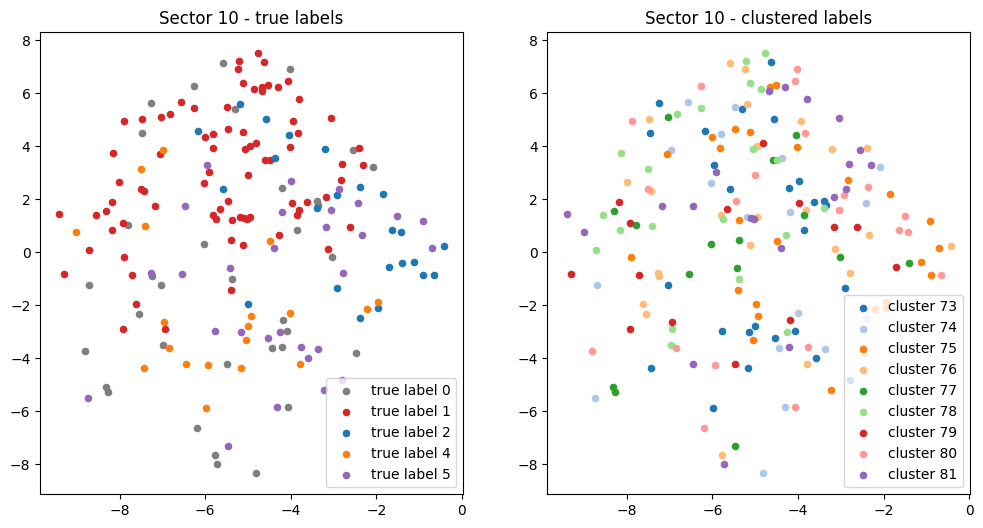

    Sector 11: 9 clusters, Labels: [82, 83, 84, 85, 86, 87, 88, 89, 90], Points: 239
      True label counts in sector 11: {2.0: 100, 5.0: 87, 0.0: 36, 4.0: 15, 3.0: 1}
      Detected cluster counts in sector 11: {82: 102, 83: 15, 84: 88, 85: 6, 86: 11, 87: 1, 88: 3, 89: 3, 90: 10}


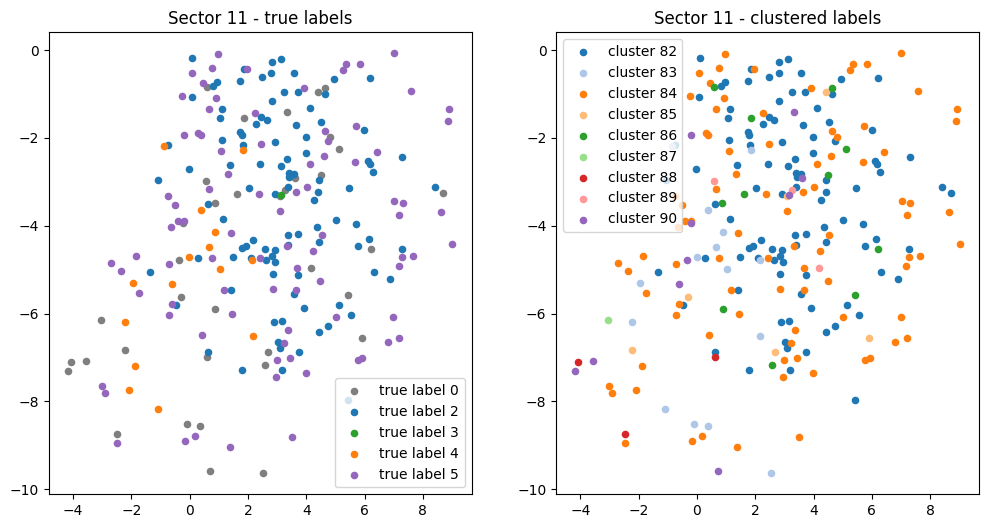

    Sector 12: 5 clusters, Labels: [91, 92, 93, 94, 95], Points: 3750
      True label counts in sector 12: {0.0: 2500, 3.0: 250, 1.0: 250, 4.0: 250, 2.0: 250, 5.0: 250}
      Detected cluster counts in sector 12: {91: 510, 92: 1472, 93: 725, 94: 453, 95: 590}


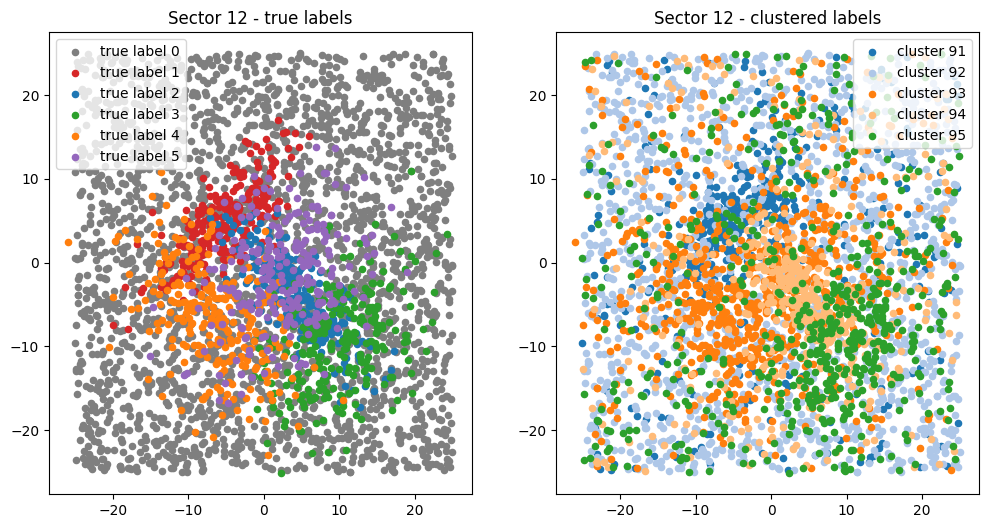

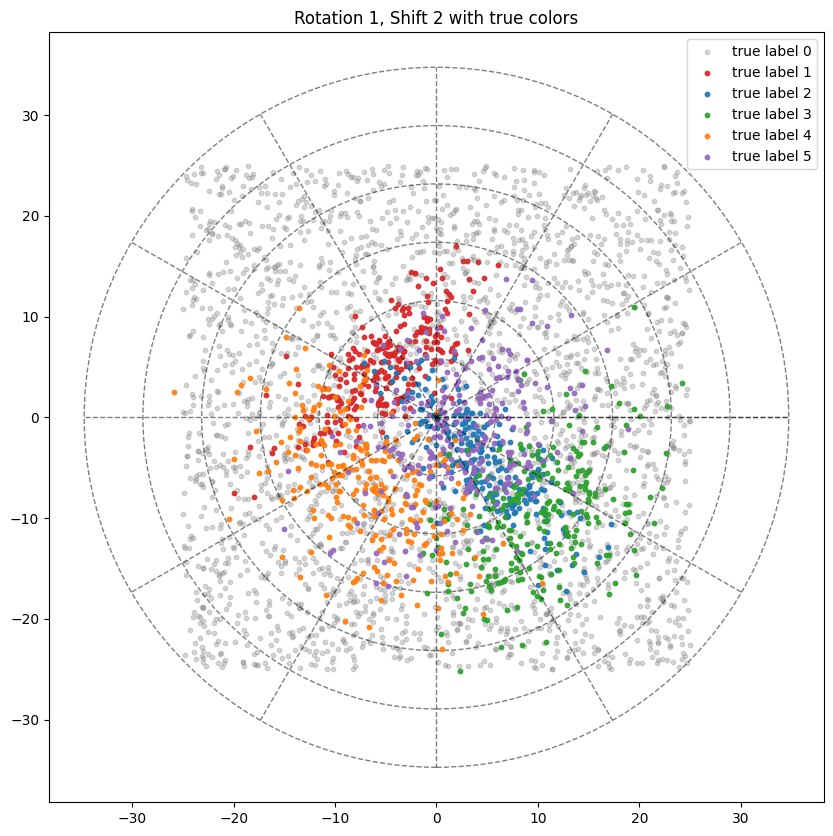

Rotation 2: Angle 180.0 degrees
  Shift 1:
    Sector 1: 9 clusters, Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8], Points: 438
      True label counts in sector 1: {0.0: 437, 4.0: 1}
      Detected cluster counts in sector 1: {0: 34, 1: 38, 2: 48, 3: 33, 4: 31, 5: 84, 6: 73, 7: 58, 8: 39}


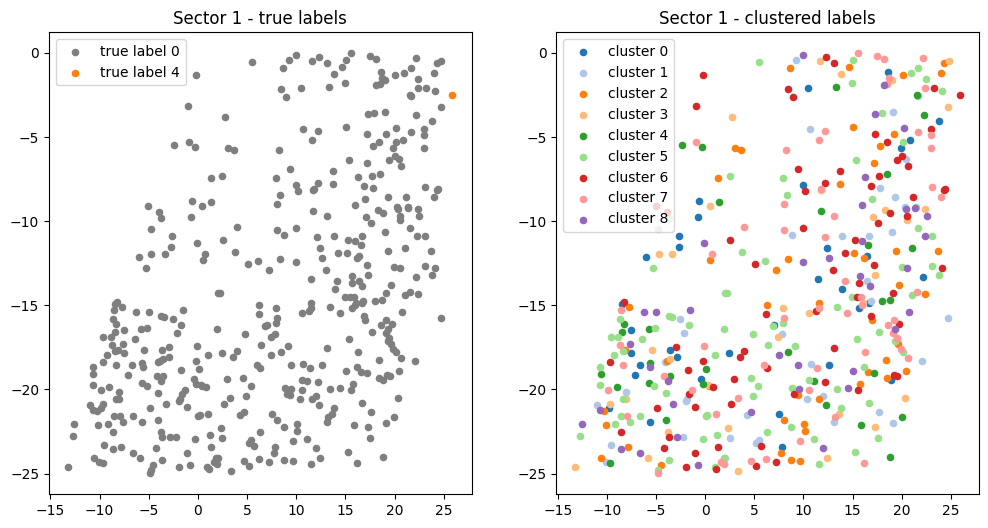

    Sector 2: 9 clusters, Labels: [9, 10, 11, 12, 13, 14, 15, 16, 17], Points: 514
      True label counts in sector 2: {0.0: 466, 3.0: 43, 2.0: 5}
      Detected cluster counts in sector 2: {9: 105, 10: 59, 11: 100, 12: 20, 13: 30, 14: 35, 15: 25, 16: 51, 17: 89}


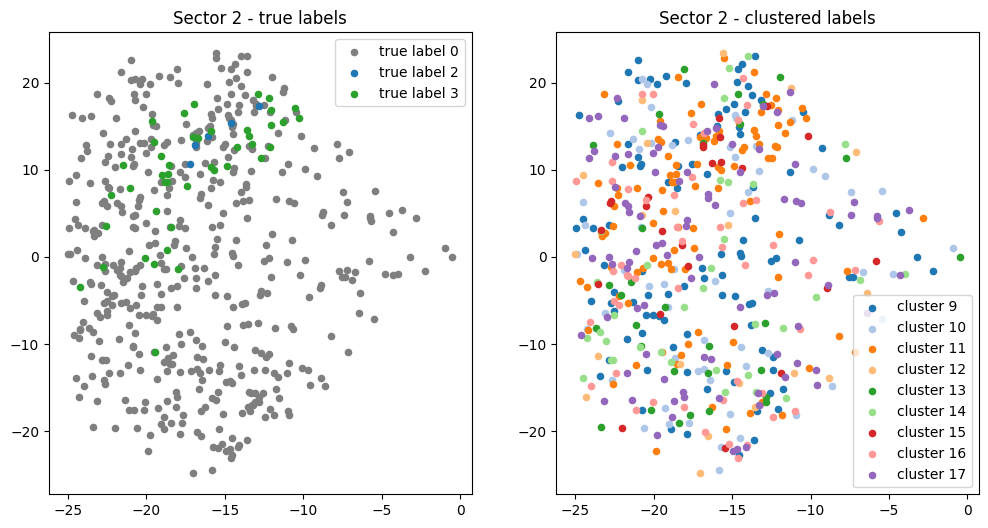

    Sector 3: 4 clusters, Labels: [18, 19, 20, 21], Points: 496
      True label counts in sector 3: {0.0: 212, 4.0: 175, 3.0: 50, 5.0: 29, 1.0: 25, 2.0: 5}
      Detected cluster counts in sector 3: {18: 215, 19: 30, 20: 64, 21: 187}


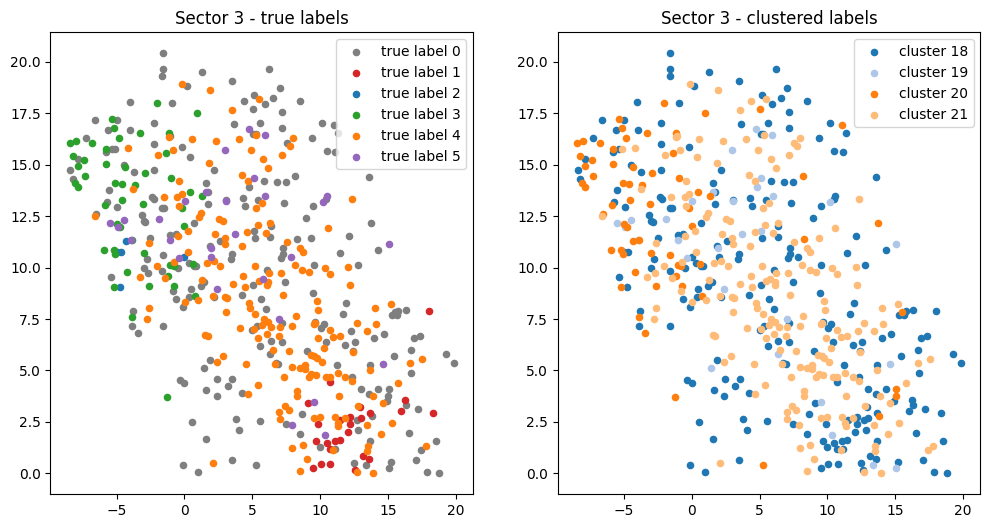

    Sector 4: 9 clusters, Labels: [22, 23, 24, 25, 26, 27, 28, 29, 30], Points: 484
      True label counts in sector 4: {0.0: 453, 3.0: 20, 4.0: 10, 1.0: 1}
      Detected cluster counts in sector 4: {22: 23, 23: 82, 24: 52, 25: 49, 26: 113, 27: 59, 28: 11, 29: 46, 30: 49}


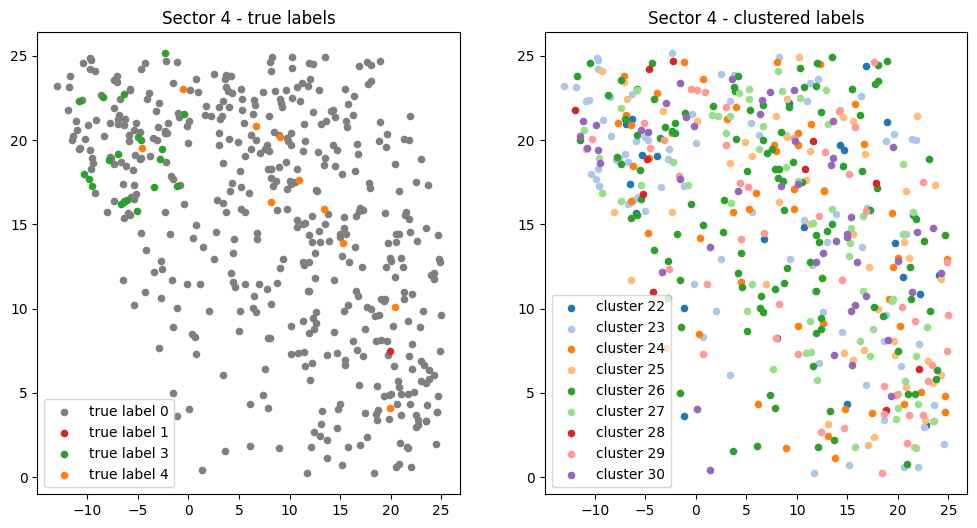

    Sector 5: 9 clusters, Labels: [31, 32, 33, 34, 35, 36, 37, 38, 39], Points: 111
      True label counts in sector 5: {0.0: 111}
      Detected cluster counts in sector 5: {31: 14, 32: 13, 33: 6, 34: 11, 35: 15, 36: 14, 37: 10, 38: 18, 39: 10}


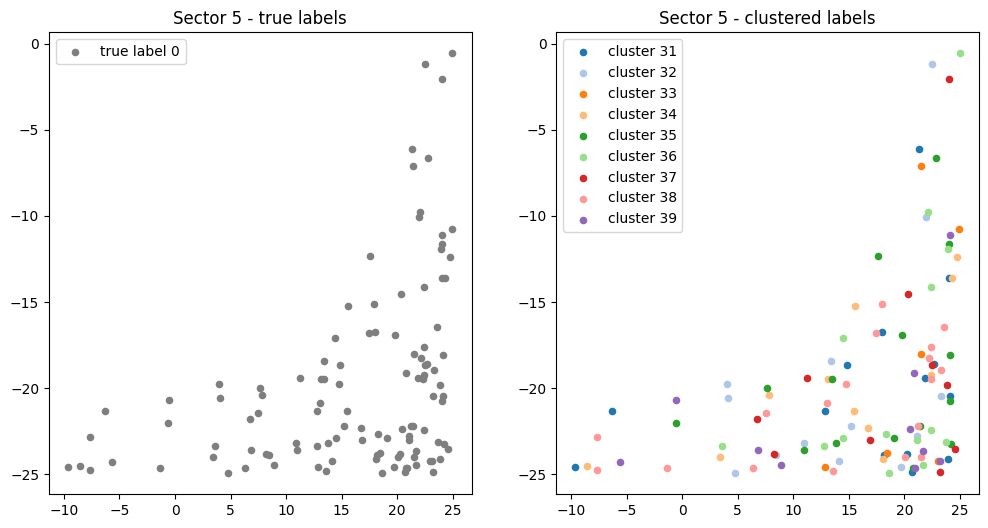

    Sector 6: 9 clusters, Labels: [40, 41, 42, 43, 44, 45, 46, 47, 48], Points: 168
      True label counts in sector 6: {0.0: 168}
      Detected cluster counts in sector 6: {40: 12, 41: 11, 42: 23, 43: 23, 44: 13, 45: 25, 46: 22, 47: 20, 48: 19}


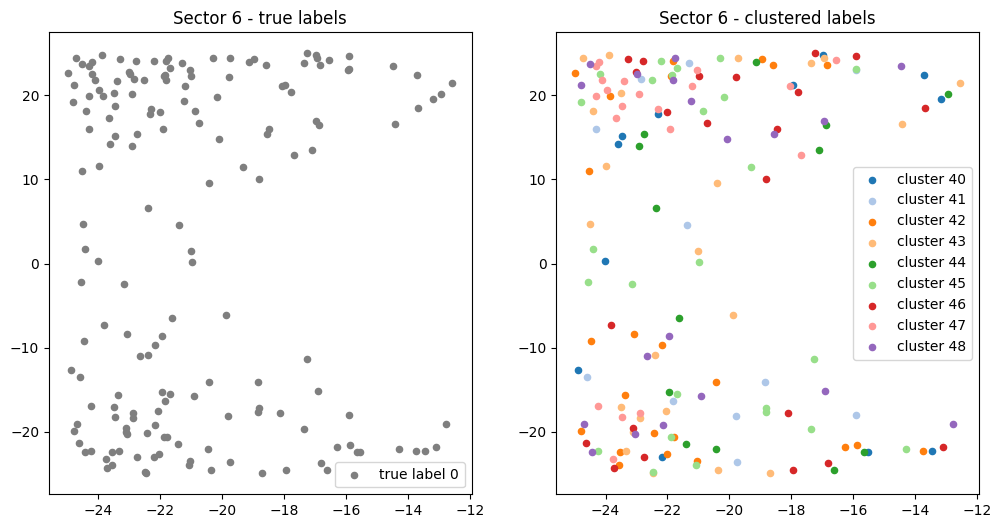

    Sector 7: 5 clusters, Labels: [49, 50, 51, 52, 53], Points: 492
      True label counts in sector 7: {0.0: 235, 3.0: 136, 2.0: 86, 5.0: 34, 4.0: 1}
      Detected cluster counts in sector 7: {49: 1, 50: 109, 51: 1, 52: 147, 53: 234}


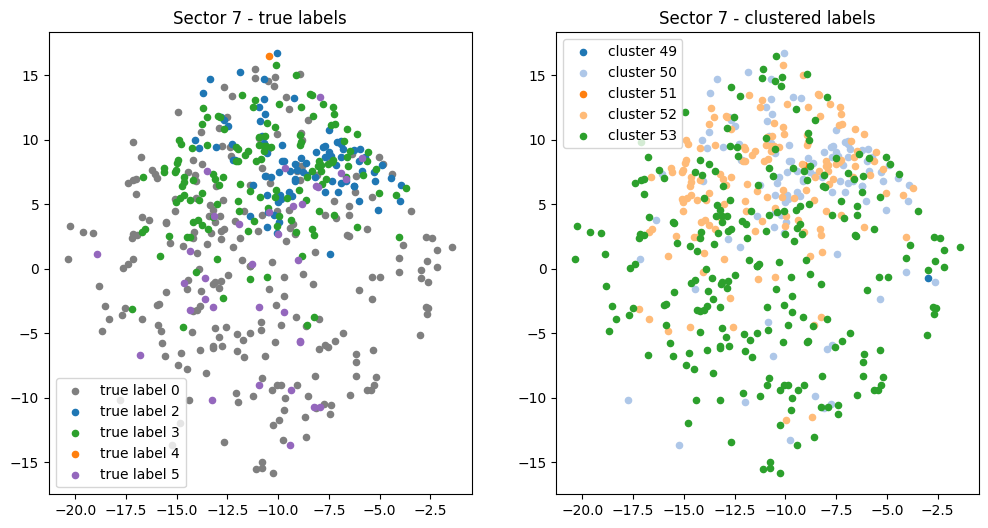

    Sector 8: 9 clusters, Labels: [54, 55, 56, 57, 58, 59, 60, 61, 62], Points: 131
      True label counts in sector 8: {0.0: 131}
      Detected cluster counts in sector 8: {54: 20, 55: 17, 56: 11, 57: 16, 58: 13, 59: 11, 60: 18, 61: 12, 62: 13}


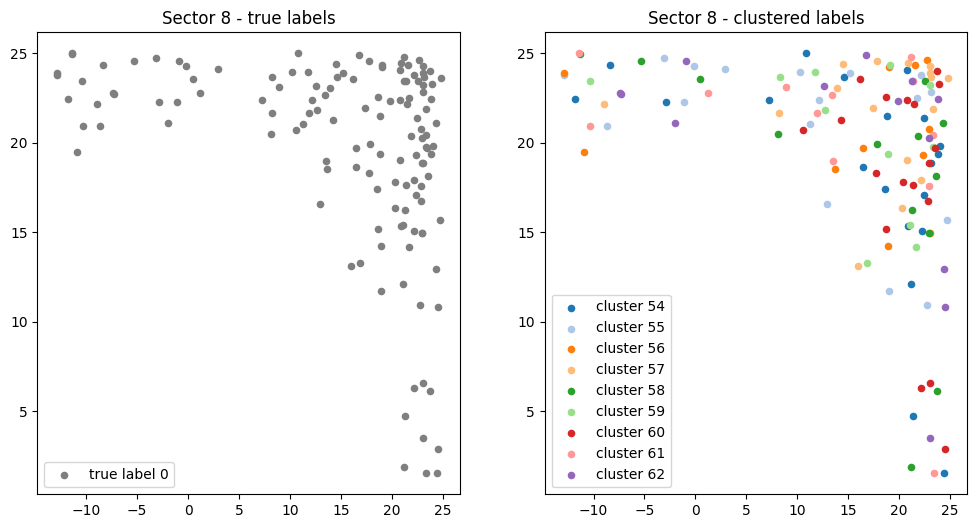

    Sector 9: 5 clusters, Labels: [63, 64, 65, 66, 67], Points: 322
      True label counts in sector 9: {0.0: 188, 1.0: 101, 4.0: 27, 5.0: 4, 2.0: 2}
      Detected cluster counts in sector 9: {63: 107, 64: 38, 65: 1, 66: 1, 67: 175}


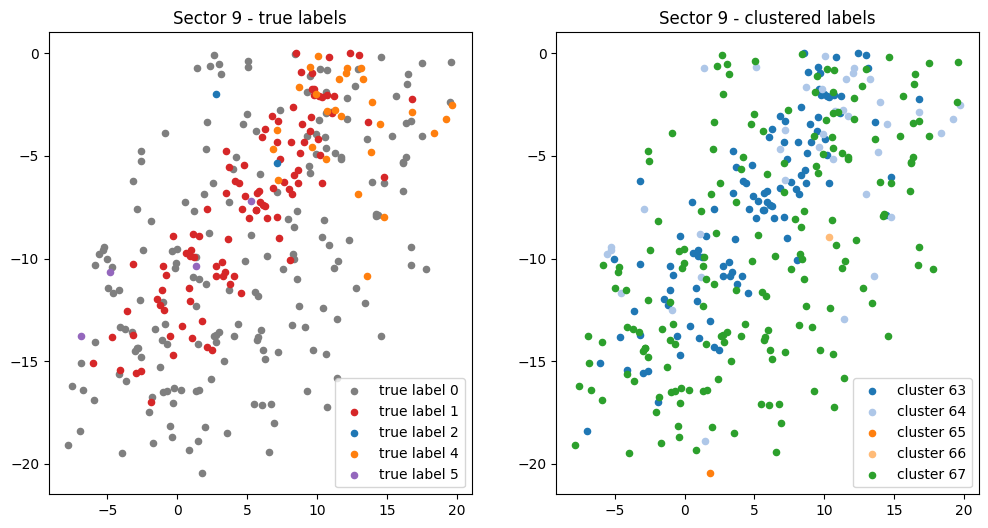

    Sector 10: 9 clusters, Labels: [68, 69, 70, 71, 72, 73, 74, 75, 76], Points: 216
      True label counts in sector 10: {1.0: 115, 5.0: 35, 0.0: 30, 2.0: 29, 4.0: 7}
      Detected cluster counts in sector 10: {68: 32, 69: 26, 70: 25, 71: 24, 72: 23, 73: 19, 74: 22, 75: 25, 76: 20}


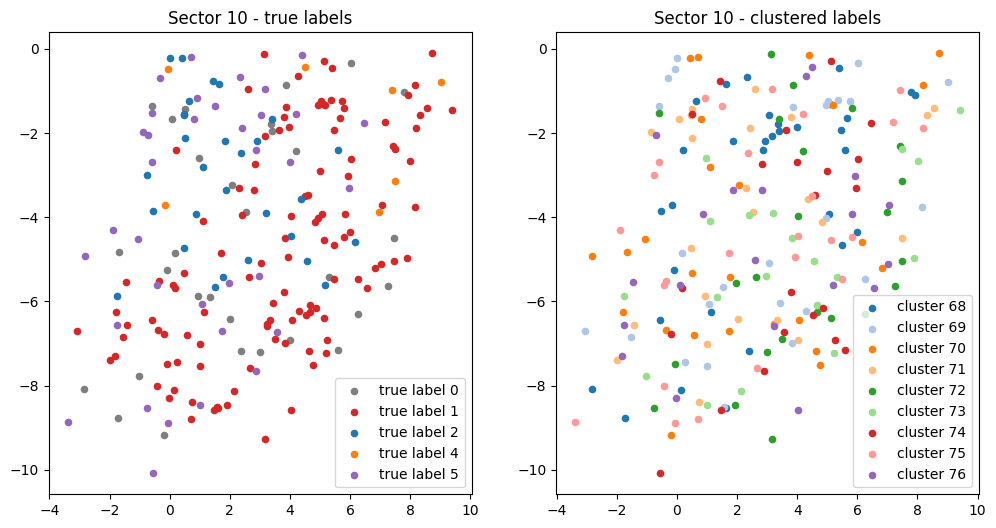

    Sector 11: 9 clusters, Labels: [77, 78, 79, 80, 81, 82, 83, 84, 85], Points: 206
      True label counts in sector 11: {5.0: 91, 2.0: 85, 0.0: 27, 1.0: 1, 3.0: 1, 4.0: 1}
      Detected cluster counts in sector 11: {77: 1, 78: 2, 79: 4, 80: 2, 81: 86, 82: 93, 83: 2, 84: 15, 85: 1}


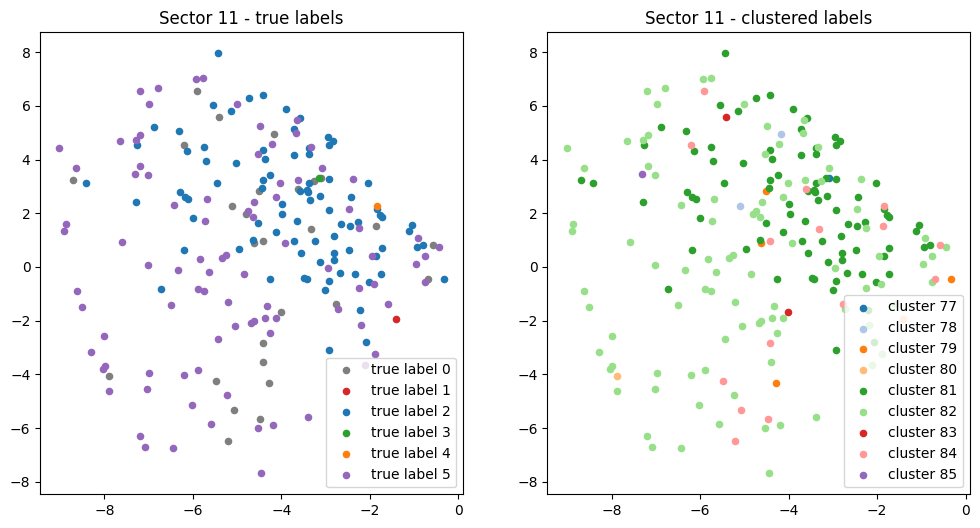

    Sector 12: 7 clusters, Labels: [86, 87, 88, 89, 90, 91, 92], Points: 3750
      True label counts in sector 12: {0.0: 2500, 4.0: 250, 2.0: 250, 3.0: 250, 1.0: 250, 5.0: 250}
      Detected cluster counts in sector 12: {86: 518, 87: 850, 88: 407, 89: 606, 90: 558, 91: 364, 92: 447}


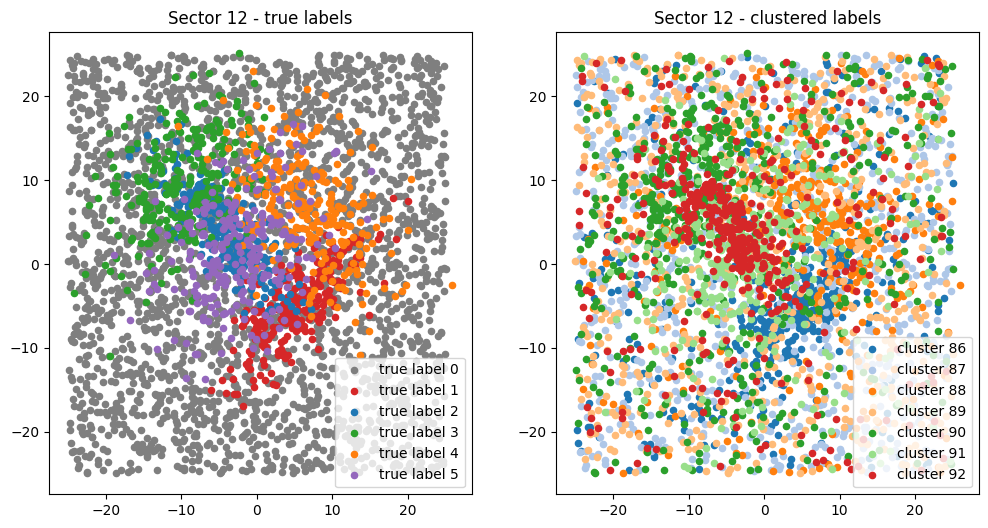

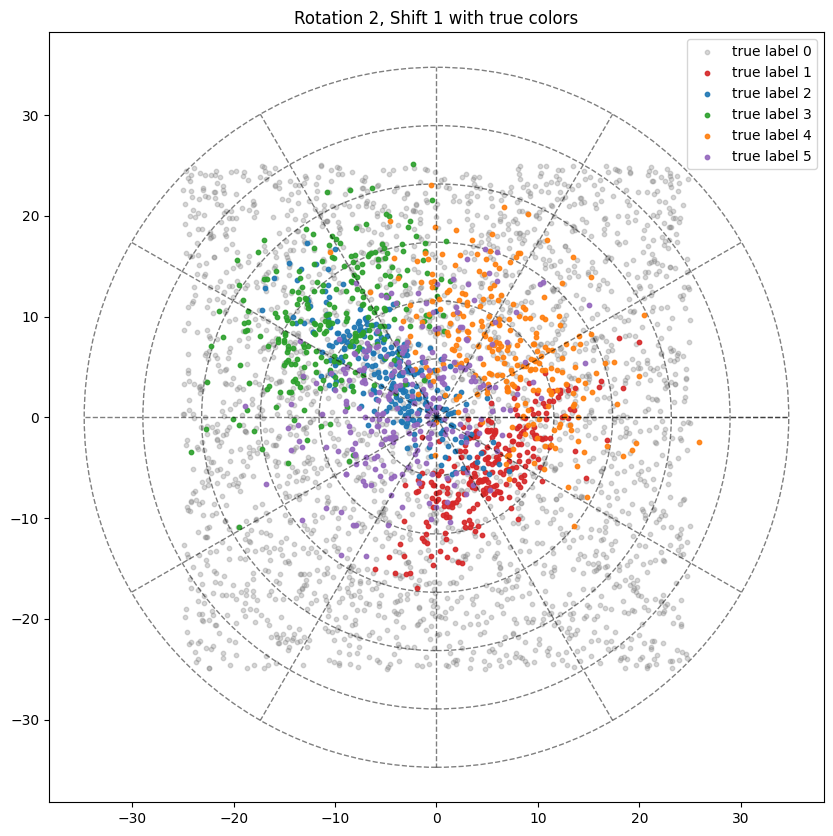

  Shift 2:
    Sector 1: 9 clusters, Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8], Points: 438
      True label counts in sector 1: {0.0: 437, 4.0: 1}
      Detected cluster counts in sector 1: {0: 34, 1: 41, 2: 11, 3: 51, 4: 21, 5: 73, 6: 65, 7: 79, 8: 63}


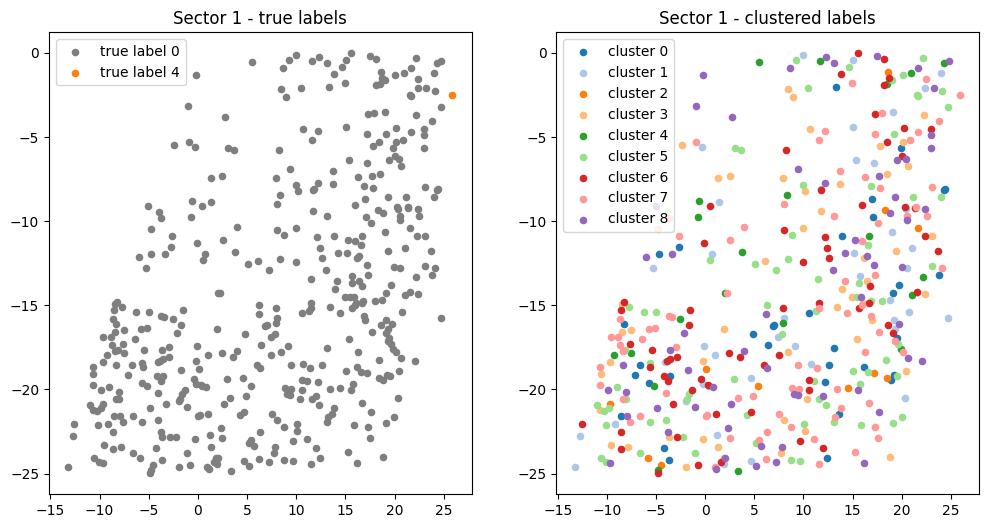

    Sector 2: 9 clusters, Labels: [9, 10, 11, 12, 13, 14, 15, 16, 17], Points: 514
      True label counts in sector 2: {0.0: 466, 3.0: 43, 2.0: 5}
      Detected cluster counts in sector 2: {9: 91, 10: 66, 11: 22, 12: 54, 13: 12, 14: 85, 15: 103, 16: 47, 17: 34}


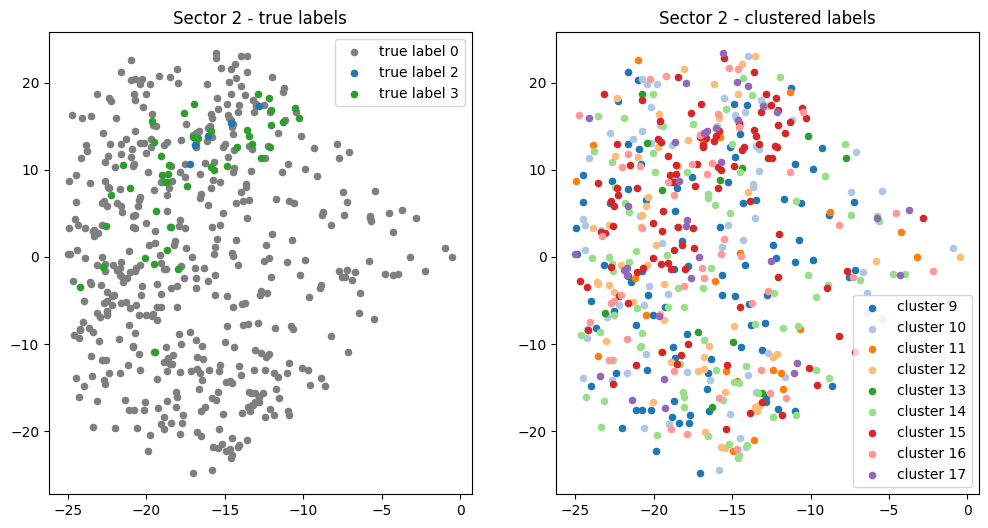

    Sector 3: 5 clusters, Labels: [18, 19, 20, 21, 22], Points: 496
      True label counts in sector 3: {0.0: 212, 4.0: 175, 3.0: 50, 5.0: 29, 1.0: 25, 2.0: 5}
      Detected cluster counts in sector 3: {18: 187, 19: 38, 20: 53, 21: 2, 22: 216}


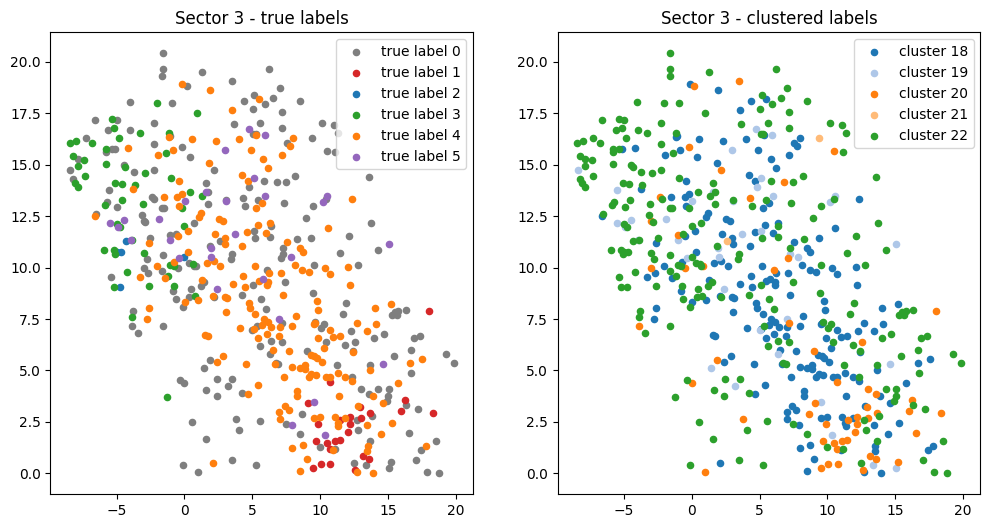

    Sector 4: 9 clusters, Labels: [23, 24, 25, 26, 27, 28, 29, 30, 31], Points: 484
      True label counts in sector 4: {0.0: 453, 3.0: 20, 4.0: 10, 1.0: 1}
      Detected cluster counts in sector 4: {23: 22, 24: 49, 25: 77, 26: 25, 27: 18, 28: 74, 29: 69, 30: 90, 31: 60}


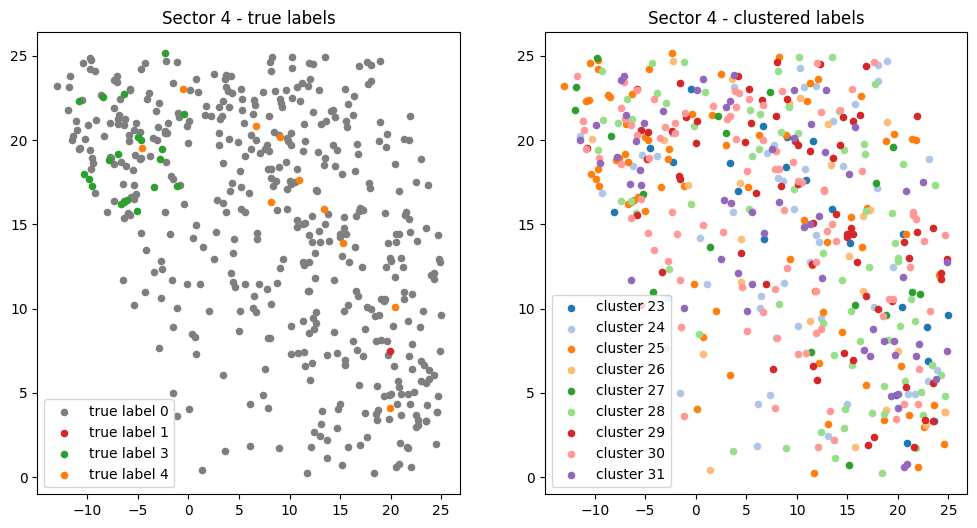

    Sector 5: 9 clusters, Labels: [32, 33, 34, 35, 36, 37, 38, 39, 40], Points: 111
      True label counts in sector 5: {0.0: 111}
      Detected cluster counts in sector 5: {32: 16, 33: 16, 34: 17, 35: 19, 36: 6, 37: 8, 38: 13, 39: 8, 40: 8}


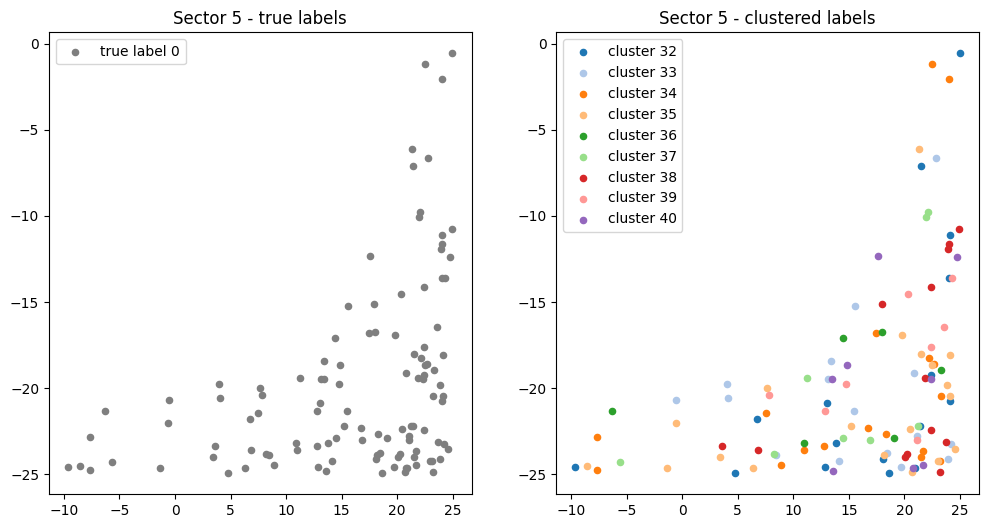

    Sector 6: 9 clusters, Labels: [41, 42, 43, 44, 45, 46, 47, 48, 49], Points: 168
      True label counts in sector 6: {0.0: 168}
      Detected cluster counts in sector 6: {41: 18, 42: 15, 43: 15, 44: 29, 45: 15, 46: 19, 47: 20, 48: 17, 49: 20}


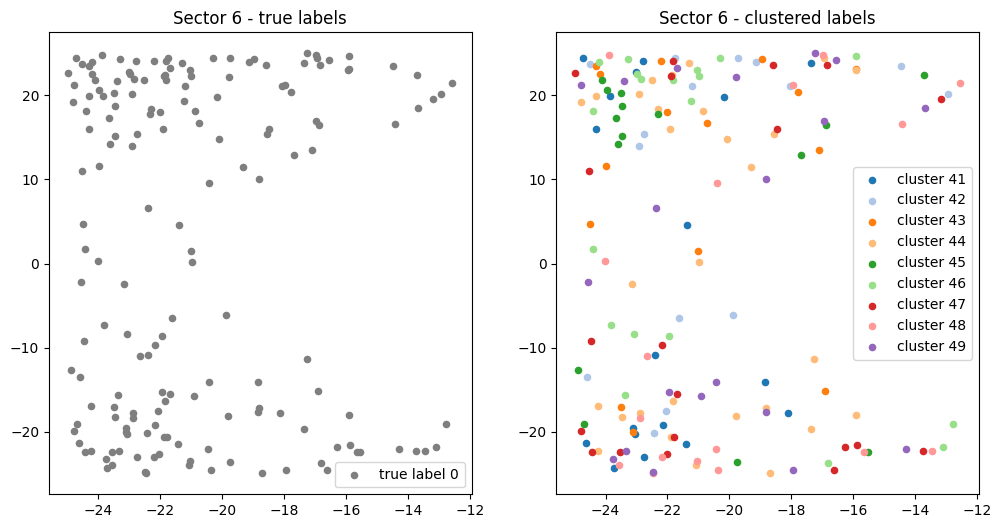

    Sector 7: 5 clusters, Labels: [50, 51, 52, 53, 54], Points: 492
      True label counts in sector 7: {0.0: 235, 3.0: 136, 2.0: 86, 5.0: 34, 4.0: 1}
      Detected cluster counts in sector 7: {50: 1, 51: 241, 52: 1, 53: 144, 54: 105}


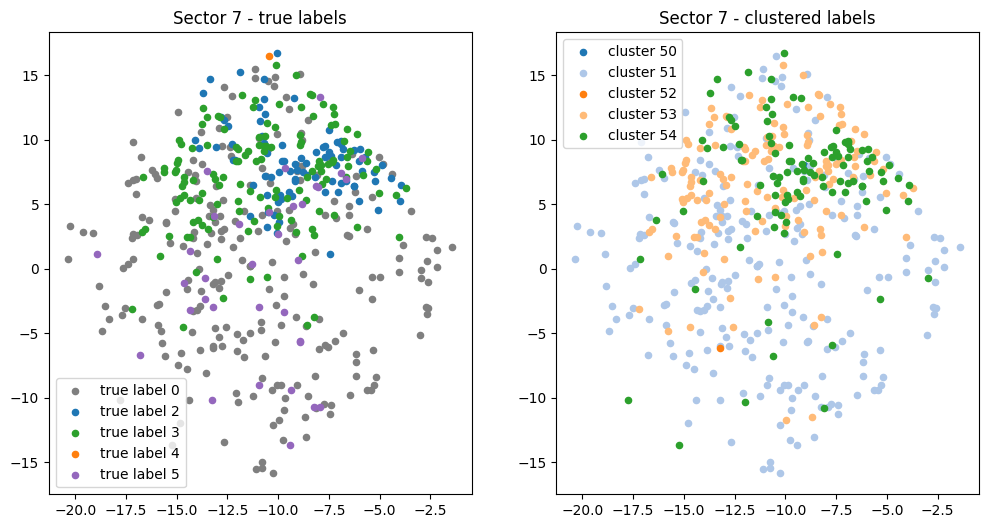

    Sector 8: 9 clusters, Labels: [55, 56, 57, 58, 59, 60, 61, 62, 63], Points: 131
      True label counts in sector 8: {0.0: 131}
      Detected cluster counts in sector 8: {55: 14, 56: 15, 57: 15, 58: 19, 59: 14, 60: 16, 61: 7, 62: 20, 63: 11}


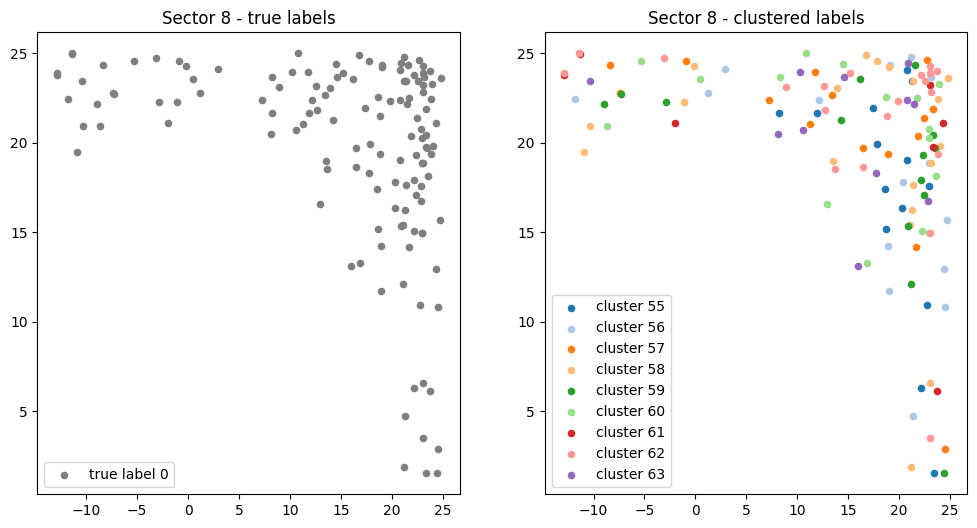

    Sector 9: 8 clusters, Labels: [64, 65, 66, 67, 68, 69, 70, 71], Points: 322
      True label counts in sector 9: {0.0: 188, 1.0: 101, 4.0: 27, 5.0: 4, 2.0: 2}
      Detected cluster counts in sector 9: {64: 4, 65: 1, 66: 2, 67: 18, 68: 11, 69: 177, 70: 108, 71: 1}


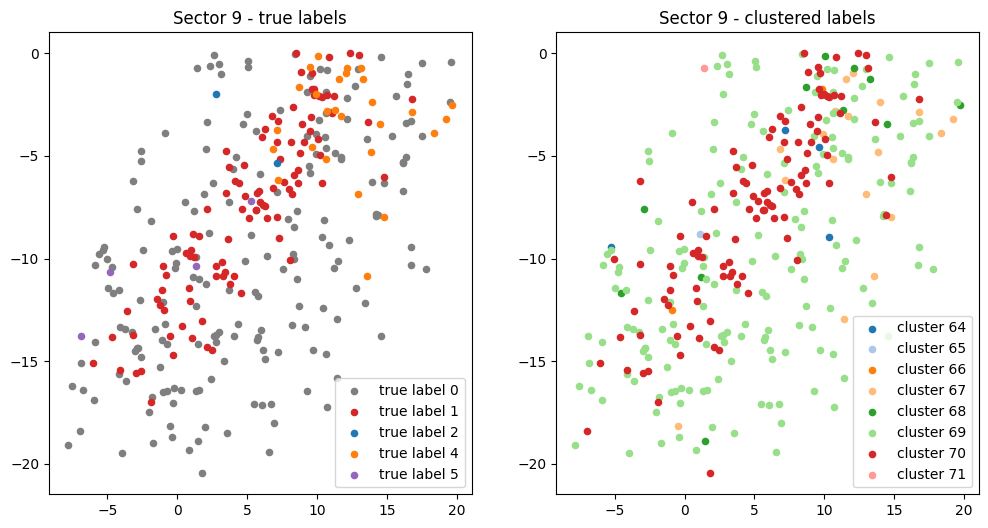

    Sector 10: 8 clusters, Labels: [72, 73, 74, 75, 76, 77, 78, 79], Points: 216
      True label counts in sector 10: {1.0: 115, 5.0: 35, 0.0: 30, 2.0: 29, 4.0: 7}
      Detected cluster counts in sector 10: {72: 1, 73: 8, 74: 3, 75: 108, 76: 1, 77: 1, 78: 1, 79: 93}


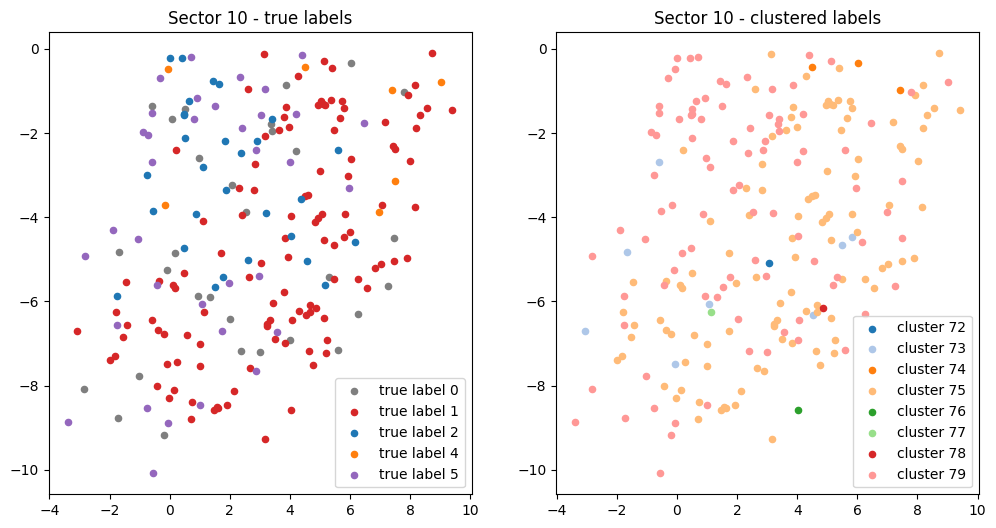

    Sector 11: 7 clusters, Labels: [80, 81, 82, 83, 84, 85, 86], Points: 206
      True label counts in sector 11: {5.0: 91, 2.0: 85, 0.0: 27, 1.0: 1, 3.0: 1, 4.0: 1}
      Detected cluster counts in sector 11: {80: 2, 81: 16, 82: 85, 83: 3, 84: 2, 85: 8, 86: 90}


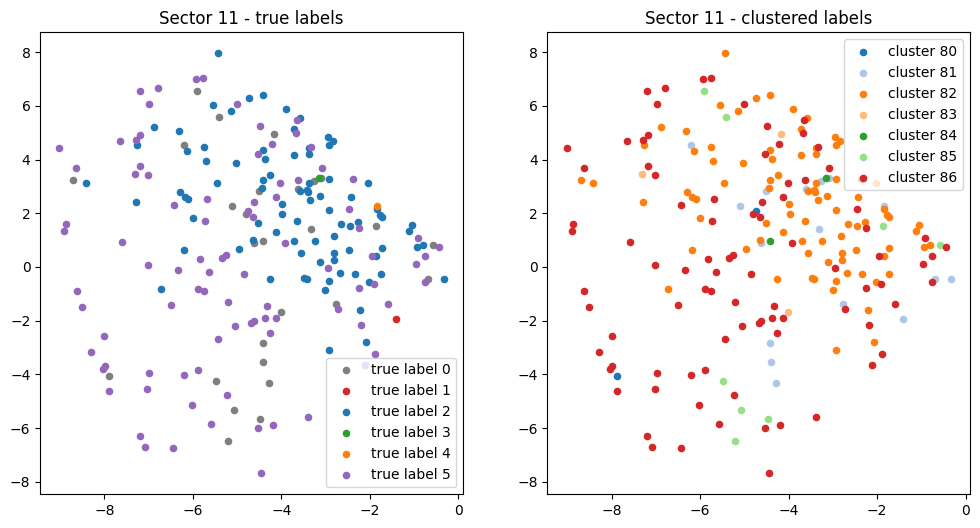

    Sector 12: 5 clusters, Labels: [87, 88, 89, 90, 91], Points: 3750
      True label counts in sector 12: {0.0: 2500, 4.0: 250, 2.0: 250, 3.0: 250, 1.0: 250, 5.0: 250}
      Detected cluster counts in sector 12: {87: 1485, 88: 584, 89: 454, 90: 710, 91: 517}


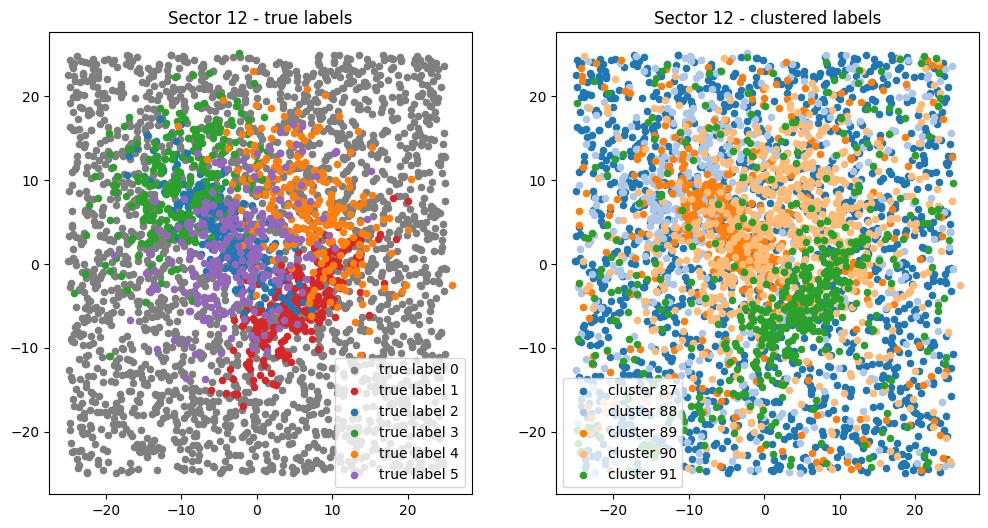

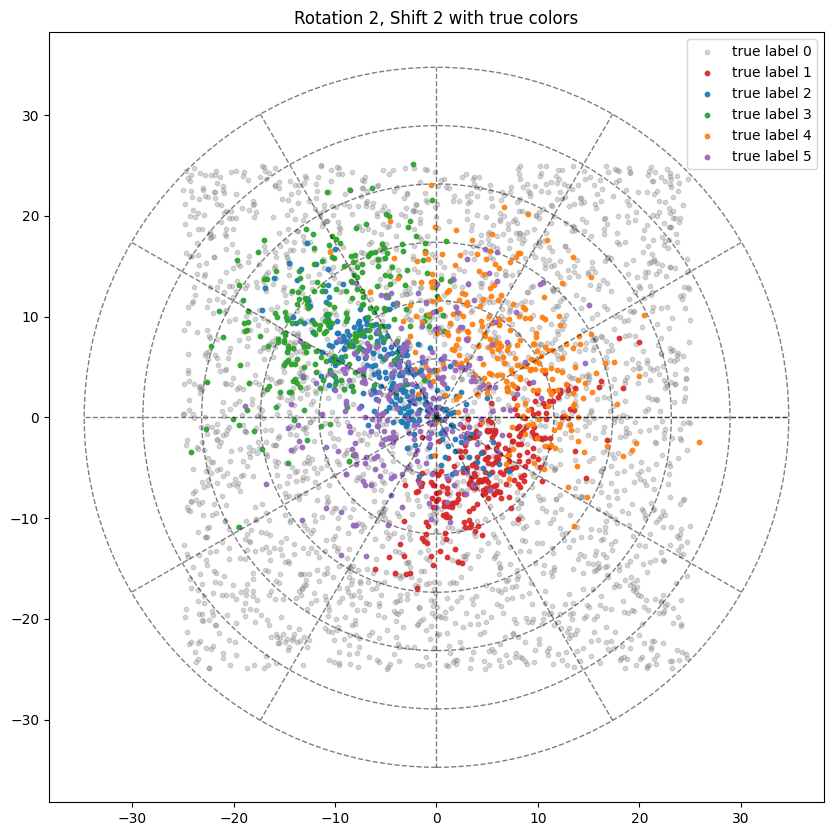

Needed time: 46.67s


In [21]:
K = 9  
consensus_labels = shell_grid.run_shell_grid_consensus_clustering(
    df, K, labels, solver='nmf', consensus_nclass=K, random_state=42, colors=colors, alphas=alphas,
    zorders=zorders, num_rotations=2, rotation_axis='z', rotation_angle=None,
    num_shifts=2, num_sectors=3, num_shells=4, projection='xy', max_iter=1_000,
    method="random", theta=0.01, epsilon=0.001,initial_partition=None, rho_multiplier=None,
    verbose=False, th_dist=2, dist_max=1e3, print_info=True, entire_G=False)

In [22]:
overall_nmi = consensus_clusterings.calculate_nmi_and_purity(consensus_labels, labels, background_label=0)

Overall NMI (ignoring background points): 0.8509

Cluster 0:
  - Number of points: 574
  - Purity (excluding background): 0.9803
  - True label distribution in this cluster:
    * Background noise: 320 points
    * True label 2.0: 5 points
    * True label 3.0: 249 points


Cluster 1:
  - Number of points: 510
  - Purity (excluding background): 0.9690
  - True label distribution in this cluster:
    * Background noise: 252 points
    * True label 1.0: 250 points
    * True label 2.0: 1 points
    * True label 4.0: 3 points
    * True label 5.0: 4 points


Cluster 2:
  - Number of points: 453
  - Purity (excluding background): 0.9683
  - True label distribution in this cluster:
    * Background noise: 201 points
    * True label 2.0: 244 points
    * True label 3.0: 1 points
    * True label 4.0: 7 points


Cluster 3: Only background points present.
  - Number of points: 120

Cluster 4: Only background points present.
  - Number of points: 135

Cluster 5:
  - Number of points: 734
  - P

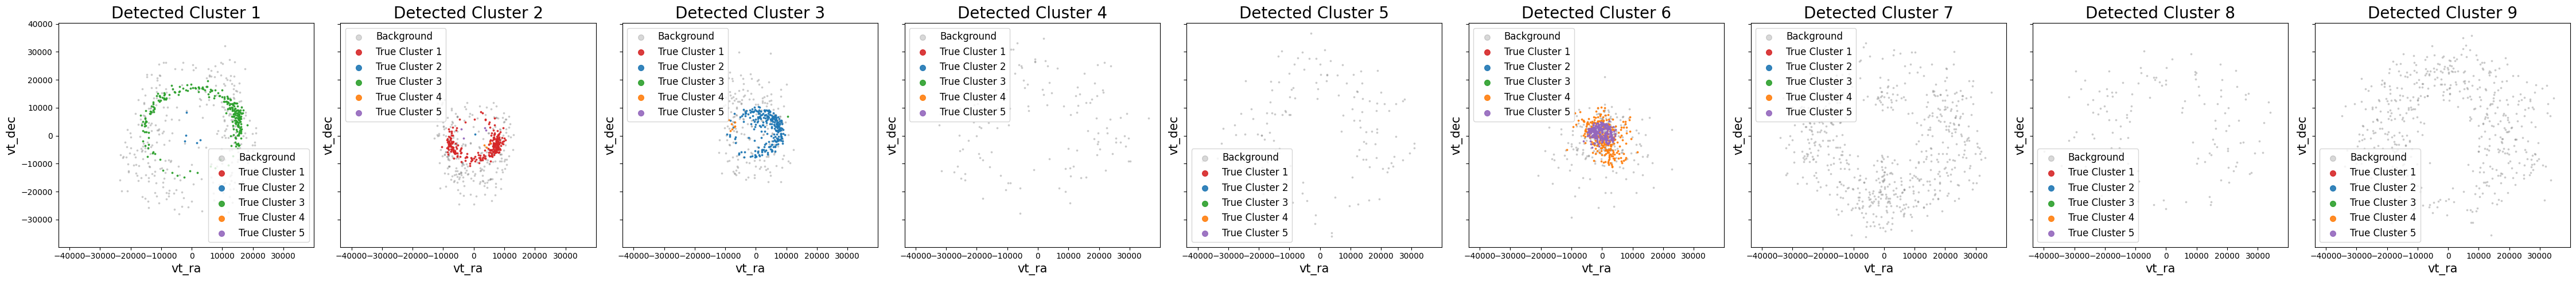

In [23]:
visualisations.visualise_cluster_result(
    df=df,
    cluster_labels=consensus_labels,
    true_labels=labels,
    K=len(np.unique(consensus_labels)),  
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)